## Imports

In [102]:
import pandas as pd
import numpy as np

# Plotting and visualization
import seaborn as sns
import matplotlib.pyplot as plt

# Scaling and Dimensionality reduction
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import VarianceThreshold

# Clusterings
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_samples, silhouette_score
from sklearn.cluster import OPTICS, cluster_optics_dbscan
from sklearn import cluster
from scipy.cluster.hierarchy import dendrogram
from scipy.cluster import hierarchy

## Task 1 - The Data 

In [103]:
# reading in the data
raw_data = pd.read_csv("ScreenTimevsMentalWellness.csv")

In [104]:
# Visualizing first five samples
raw_data.head()

,user_id,age,gender,occupation,work_mode,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
0,U0001,33,Female,Employed,Remote,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3,NaN
1,U0002,28,Female,Employed,In-person,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2,NaN
2,U0003,35,Female,Employed,Hybrid,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6,NaN
3,U0004,42,Male,Employed,Hybrid,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0,NaN
4,U0005,28,Male,Student,Remote,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0,NaN


**The Data and its suitability for the project**

The Data:

Features represent lifestyle choices, screentime habits, mental wellness scored and user information like gender and age.
For a lot of features the units are either hours (with one exception being minutes) or rankings in fixed ranges like the sleep quality between 1 and 5 or stress level between 0 and 10. All the scores are self perceived by the users.

Suitability for the project:

The data is about a questionaire on mental wellness and screentime habits, which includes various numerical features in which people have ranked their mental wellbeing in fixed ranges. 
The data is suitable for my task, as it is very recent - the questionaire is from 2025 - and included a variety of features all to do with mental health and screentimes, as well as other relevant lifestyle choices. Furthermore, the data is in fixed ranges, the sleep quality for example is ranged between 1 and 5, making data more comparable.

## Task 2 - Initial Data Analysis 

In [105]:
# looking at the shape of the data 
print(raw_data.shape)

(400, 16)


In [106]:
# looking at unique values, special interest in categorical data
print(raw_data.nunique())

user_id                        400
age                             36
gender                           3
occupation                       5
work_mode                        3
screen_time_hours              314
work_screen_hours              262
leisure_screen_hours           316
sleep_hours                    230
sleep_quality_1_5                4
stress_level_0_10               73
productivity_0_100             276
exercise_minutes_per_week      196
social_hours_per_week          159
mental_wellness_index_0_100    263
Unnamed: 15                      0
dtype: int64


In [107]:
# Looking for NaN values 
print(raw_data.isnull().sum())

user_id                          0
age                              0
gender                           0
occupation                       0
work_mode                        0
screen_time_hours                0
work_screen_hours                0
leisure_screen_hours             0
sleep_hours                      0
sleep_quality_1_5                0
stress_level_0_10                0
productivity_0_100               0
exercise_minutes_per_week        0
social_hours_per_week            0
mental_wellness_index_0_100      0
Unnamed: 15                    400
dtype: int64


Observation: There are no NaN values in the data, meaning the data does not need any processing in concern to NaN values.

In [108]:
# checking for duplicates, sum() counts the True values
raw_data.duplicated().sum() 

np.int64(0)

Observation: There are no duplicates in the data, meaning no rows need to be deleted due to duplication

In [109]:
# statistical analysis of unprocessed data
raw_data.describe()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100,Unnamed: 15
count,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,0.0
mean,29.77750,9.024900,2.183075,6.841825,7.013175,1.397500,8.150500,54.306500,109.810000,7.905000,20.326750,NaN
std,7.46608,2.491058,1.931321,2.220896,0.852421,0.652348,2.094844,15.020054,70.007045,4.909632,20.376793,NaN
min,16.00000,1.000000,0.110000,0.890000,4.640000,1.000000,0.000000,20.600000,0.000000,0.000000,0.000000,NaN
25%,24.00000,7.372500,0.695000,5.460000,6.397500,1.000000,6.900000,43.600000,58.000000,4.575000,3.675000,NaN
50%,30.00000,9.090000,1.455000,6.700000,7.030000,1.000000,8.800000,51.750000,103.000000,7.750000,14.800000,NaN
75%,35.00000,10.495000,3.012500,8.417500,7.640000,2.000000,10.000000,63.000000,157.000000,11.025000,30.650000,NaN
max,60.00000,19.170000,12.040000,13.350000,9.740000,4.000000,10.000000,100.000000,372.000000,23.900000,97.000000,NaN


In [110]:
# looking at datatypes 
print(raw_data.dtypes)

user_id                         object
age                              int64
gender                          object
occupation                      object
work_mode                       object
screen_time_hours              float64
work_screen_hours              float64
leisure_screen_hours           float64
sleep_hours                    float64
sleep_quality_1_5                int64
stress_level_0_10              float64
productivity_0_100             float64
exercise_minutes_per_week        int64
social_hours_per_week          float64
mental_wellness_index_0_100    float64
Unnamed: 15                    float64
dtype: object


Observation: There are a lot of numerical values, of which most in the float format. What to do with the categorical features will be decided in the preprocessing step.

In [111]:
# Checking for outliers in the data that are not logically possible
print((raw_data["age"] > 100).sum()) # checking for too high ages
print((raw_data["age"] < 16).sum()) # checking wether very young ages occur
print((raw_data["screen_time_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["work_screen_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["leisure_screen_hours"] > 20).sum()) # assuming at least 4 hours of sleep 
print((raw_data["sleep_hours"] > 10).sum()) # checking for too high sleep counts
print((raw_data["sleep_quality_1_5"].isin(range(1,6))).sum()) # checking wether all data is in allowed range of 1-5
print((raw_data["stress_level_0_10"] > 10).sum()) # checking wether data is above allowed range
print((raw_data["stress_level_0_10"] < 0).sum()) # checking wether data is below allowed range (negative)
print((raw_data["productivity_0_100"] > 100).sum()) # checking wether data is above allowed range
print((raw_data["productivity_0_100"] < 0).sum())# checking wether data is below allowed range (negative)
print((raw_data["exercise_minutes_per_week"] > 390).sum()) # assuming 6.5 hours a week for a start (more can still be logical) --> no further experiments needed, as all values are within 5 hours a week
print((raw_data["social_hours_per_week"] > 35).sum()) # assuming 4 hours a day for a start (more can still be logical) --> no further experiments needed, as all values are within 35 hours 
print((raw_data["mental_wellness_index_0_100"] > 100).sum())# checking wether data is above allowed range 
print((raw_data["mental_wellness_index_0_100"] < 0).sum())# checking wether data is below allowed range (negative)


0
0
0
0
0
0
400
0
0
0
0
0
0
0
0


Observation: There are no outliers that need to be handled because they are not logical. All data is logical, meaning that it either fits within expected times (there cannot be more than 24 hours of anything in a day and some sleep is always needed for example) or fits within the given ranges (for example sleep quality had to be stated in an integer range between 1 and 5).

## Task 3 – Preprocessing

In [112]:
# dropping columns
raw_data.drop(columns= ["user_id", "gender", "occupation", "work_mode", "Unnamed: 15"], inplace=True)

I have dropped the column user_id, as it is redundant with the index. Further, I have dropped the column Unnamed: 15, as it does not contain any viable information.
Besides that, I have dropped the columns gender, occupation and work_mode. All three are represented as categorical data, making a statistical analysis difficult. For gender I have also decided to drop the column because I want to cluster the data without looking at the gender as to not overcomplicate things. Furthermore, I have dropped work_mode, since it is not important for my analysis wether the screentime happens in remote, hybrid or at work. Occupation I have dropped, because I do not want to rate the different forms of occupation and I do not want to differentiate between them. All people answering the survey have divided their screentime into productive and leisure screen hours and for the purpose of the project, it does not matter how the productive screen hours are spent, wether for work or university or otherwise. 

In [113]:
# dataframe after dropping columns
raw_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,exercise_minutes_per_week,social_hours_per_week,mental_wellness_index_0_100
0,33,10.79,5.44,5.35,6.63,1,9.3,44.7,127,0.7,9.3
1,28,7.40,0.37,7.03,8.05,3,5.7,78.0,74,2.1,56.2
2,35,9.78,1.09,8.69,6.48,1,9.1,51.8,67,8.0,3.6
3,42,11.13,0.56,10.57,6.89,1,10.0,37.0,0,5.7,0.0
4,28,13.22,4.09,9.13,5.79,1,10.0,38.5,143,10.1,0.0


In [114]:
# transforming exercise column from minutes to hours
raw_data["exercise_hours_per_week"] = round(raw_data["exercise_minutes_per_week"] / 60,2)

In [115]:
raw_data["exercise_hours_per_week"] # seeing wether transformation was done correctly

0      2.12
1      1.23
2      1.12
3      0.00
4      2.38
       ... 
395    4.20
396    1.65
397    3.22
398    1.62
399    1.47
Name: exercise_hours_per_week, Length: 400, dtype: float64

In [116]:
raw_data.drop(columns=["exercise_minutes_per_week"], inplace = True) # dropping original exercise column
raw_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,33,10.79,5.44,5.35,6.63,1,9.3,44.7,0.7,9.3,2.12
1,28,7.40,0.37,7.03,8.05,3,5.7,78.0,2.1,56.2,1.23
2,35,9.78,1.09,8.69,6.48,1,9.1,51.8,8.0,3.6,1.12
3,42,11.13,0.56,10.57,6.89,1,10.0,37.0,5.7,0.0,0.00
4,28,13.22,4.09,9.13,5.79,1,10.0,38.5,10.1,0.0,2.38


I have transformed the exercise column from minutes into hours, as it was the only column stating numbers in minutes, every other feature is displayed in hours. Therefore, transforming the column makes the data more comparable. This could also be achieved through scaling, but I have still chosen to transform the column to make initial analysis and experiments on unscaled data more comparable. I have rounded the numbers slightly and have decided that the small changes in numbers are an okay loss compared to the gain of more comparable data, as the numbers are high enough that a few minutes lost or added do not change the overall perceptio of wether someone does a lot or only a little exercise in a week.

Observation: As there are no NaN values and no duplicates in the data, no further preprocessing steps are needed at this point.

In [117]:
# final, cleaned dataset
data_full = raw_data 

In [118]:
data_full.shape

(400, 11)

Observation: After preprocessing, the data still has 400 rows, as none were deleted, and 11 numerical features are left. 

## Task 4 – Exploratory Data Analysis: Statistical Properties

In [119]:
# correlation between colummns 
data_full.corr()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
age,1.000000,0.069340,0.074443,0.013039,0.053503,-0.017816,0.046246,-0.088678,0.024754,-0.051935,0.040738
screen_time_hours,0.069340,1.000000,0.519950,0.669490,-0.331314,-0.278365,0.697812,-0.706537,-0.198124,-0.635943,-0.171781
work_screen_hours,0.074443,0.519950,1.000000,-0.286414,-0.133243,-0.100854,0.307424,-0.335697,-0.051876,-0.286261,-0.078260
leisure_screen_hours,0.013039,0.669490,-0.286414,1.000000,-0.255747,-0.224523,0.515358,-0.500558,-0.177113,-0.464366,-0.124622
sleep_hours,0.053503,-0.331314,-0.133243,-0.255747,1.000000,0.614381,-0.481137,0.517313,0.023130,0.580824,0.188516
sleep_quality_1_5,-0.017816,-0.278365,-0.100854,-0.224523,0.614381,1.000000,-0.558870,0.644802,0.017767,0.750092,0.095326
stress_level_0_10,0.046246,0.697812,0.307424,0.515358,-0.481137,-0.558870,1.000000,-0.879539,-0.114268,-0.913818,-0.159623
productivity_0_100,-0.088678,-0.706537,-0.335697,-0.500558,0.517313,0.644802,-0.879539,1.000000,0.117232,0.902249,0.131906
social_hours_per_week,0.024754,-0.198124,-0.051876,-0.177113,0.023130,0.017767,-0.114268,0.117232,1.000000,0.070400,0.019324
mental_wellness_index_0_100,-0.051935,-0.635943,-0.286261,-0.464366,0.580824,0.750092,-0.913818,0.902249,0.070400,1.000000,0.228561


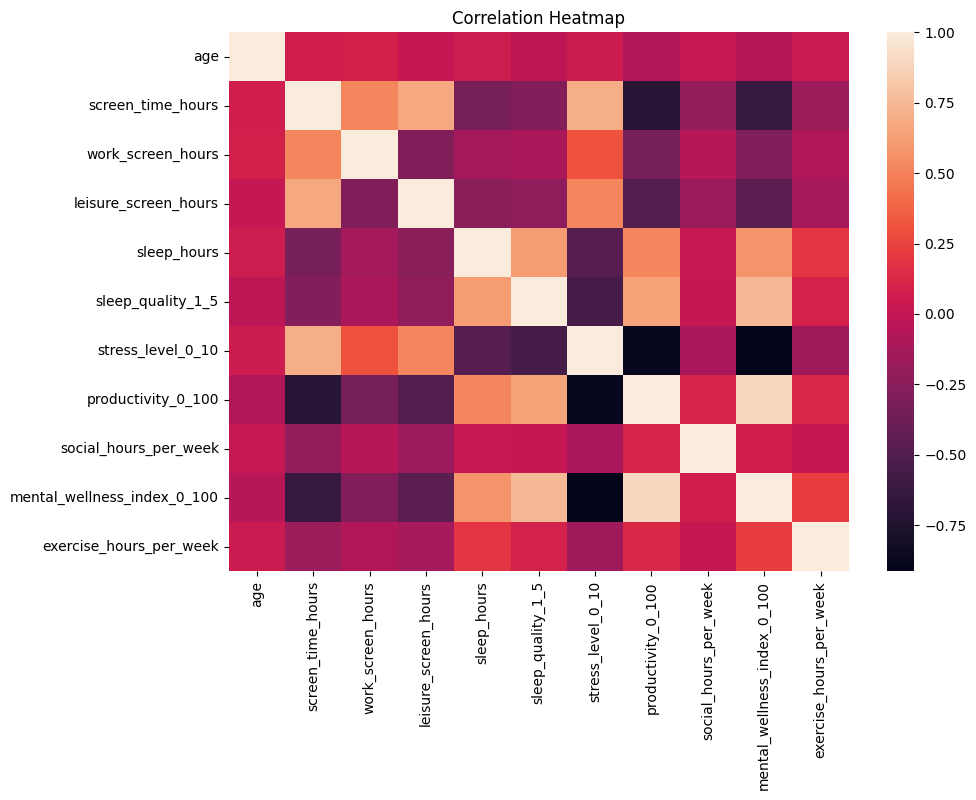

In [120]:
# correlation heatmap to visualize above correlation
plt.figure(figsize=(10, 7))
sns.heatmap(data_full.corr())
plt.title("Correlation Heatmap")
plt.show()

Observation: The above heatmap shows that there are some strong correlations, for example stress level and mental wellness index have a strong negative correlation, as well as stress level and productivity. A fairly strong positive correlation of about 0.8-0.9 can be found between productivity and mental wellness index. Another fairly strong negative correlation can be found between screentime hours and the mental wellness index and an even stronger one between screen time hours and productivity.
While these correlations do not mean causation, they can be an indicator for where to look closer.

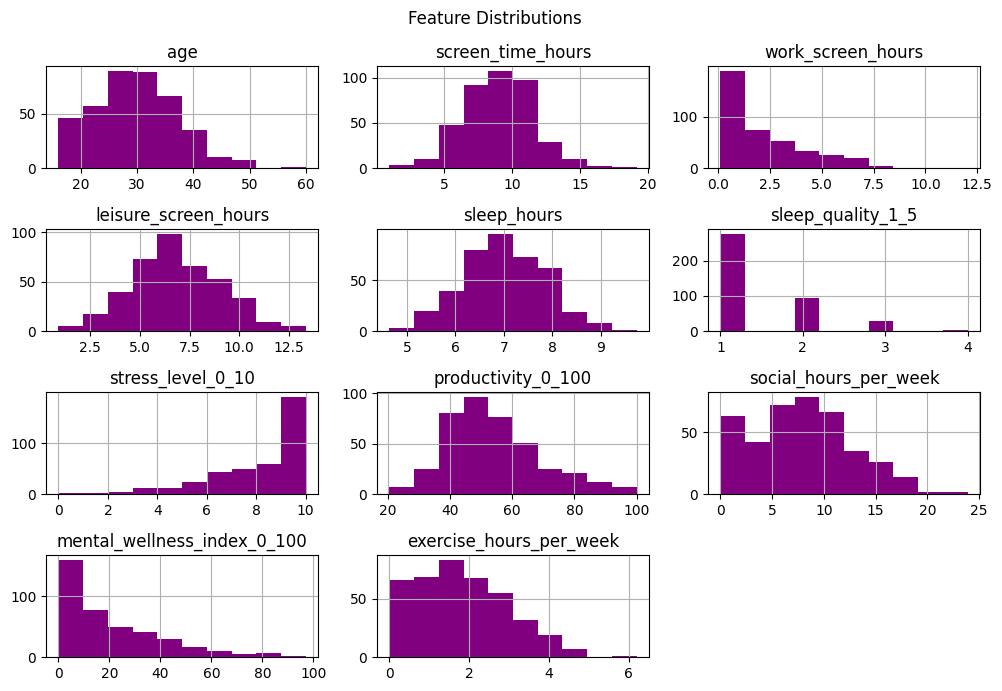

In [121]:
# Plotting the distribution of each feature
data_full.hist(figsize=(10, 7), color = "purple")
plt.suptitle('Feature Distributions')
plt.tight_layout()
plt.show()

Observation: The above plots show how the values are distributed across each feature. Looking at the stress level for example, many people reportet a stress lebel of 9-10 and only a few a stresslevel between 0 and 6. When looking at the mental wellness index, the graph looks the same just mirrored, with many people reporting a low mental wellness index and only few a higher one - this again visualizes the strong negative correlation between the features.

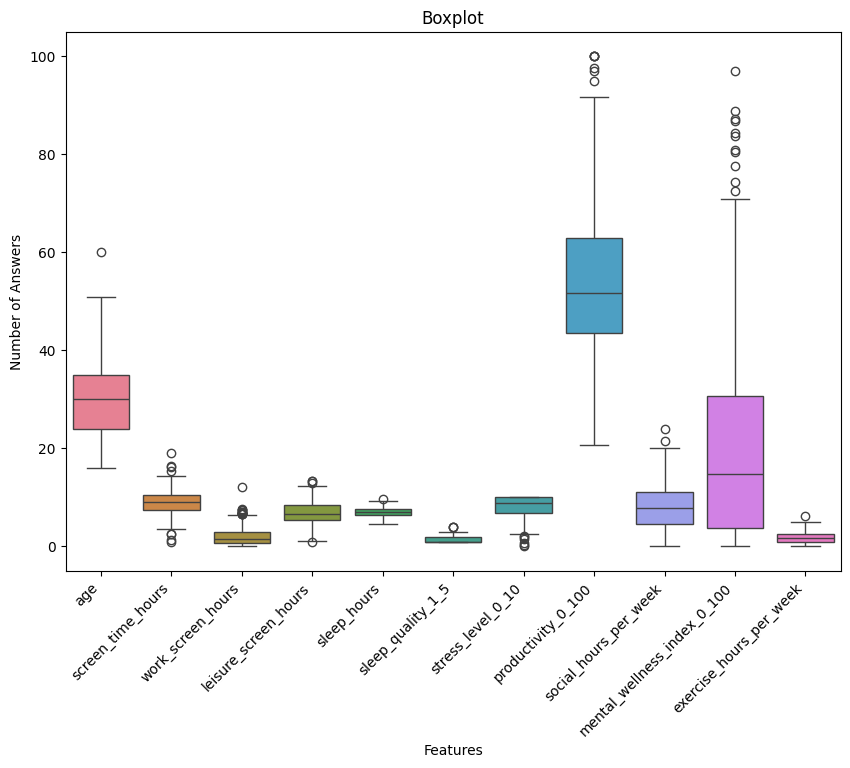

In [122]:
# Box plots
plt.figure(figsize=(10, 7))
sns.boxplot(data=data_full)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Number of Answers")
plt.title("Boxplot")
plt.show()

Observation: The boxplots show how the features are distributes on one scale. Furthermore, they show the outliers. For some features, there are a couple of outliers, especially for the mental wellness index and the productivity. Furthermore, mental wellness index and productivity also have the largest range.

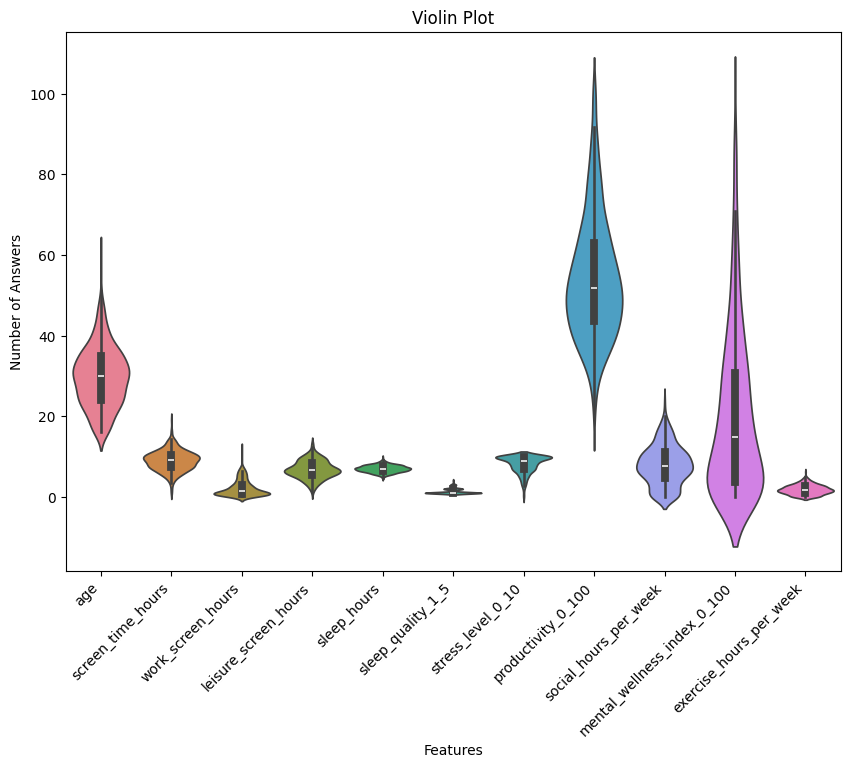

In [123]:
# Violin plots
plt.figure(figsize=(10, 7))
sns.violinplot(data=data_full)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Number of Answers")
plt.title("Violin Plot")
plt.show()

Observation: The violin plots again show the distribution across all featurs on one scale, as well as the density of each feature.
As with the boxplots, exercise minutes per weeek is very dominant in this scale, as it is measured in minutes and therefore has much higher numbers than other features.

In [124]:
# dropping dominant feature for further visualization
data = data_full.drop(columns=["productivity_0_100", "mental_wellness_index_0_100"])

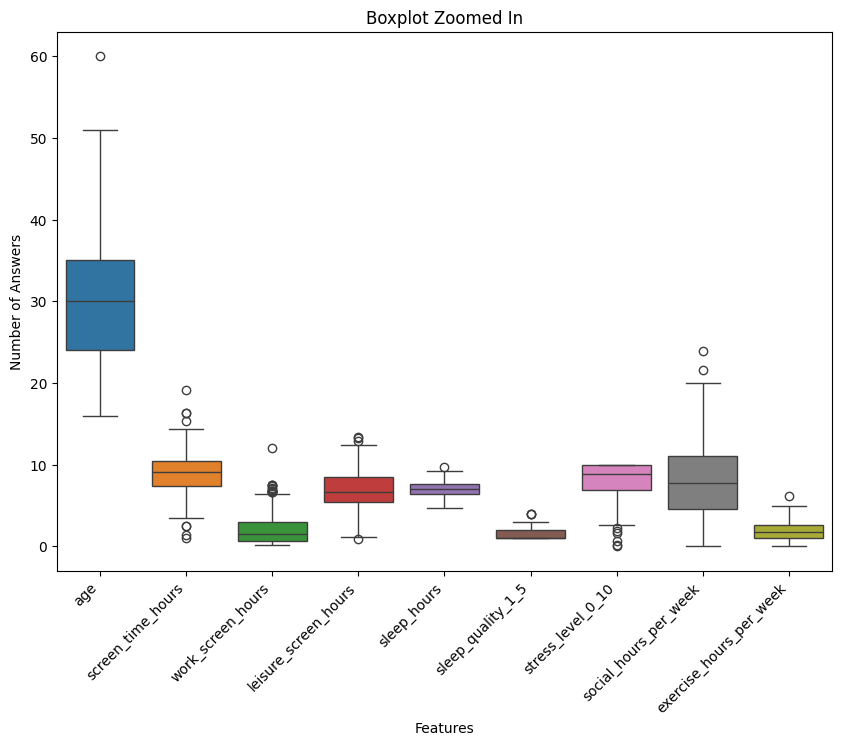

In [125]:
# New Box plots
plt.figure(figsize=(10, 7))
sns.boxplot(data=data)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Number of Answers")
plt.title("Boxplot Zoomed In")
plt.show()

Observation: Dropping the dominant feature for this second boxplot visualization allows are more detailed look at the other features, their distributions and outliers. This achieves a "zoomed in" look at the features.

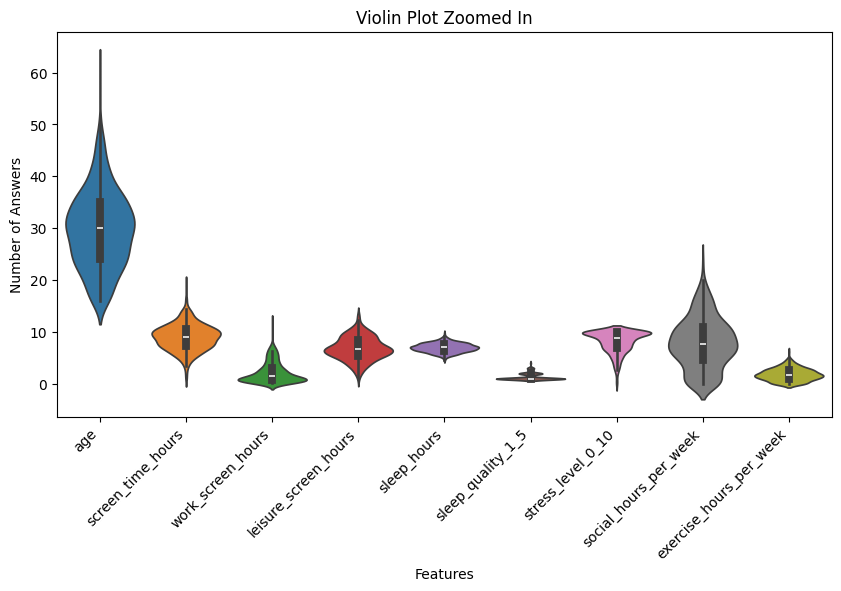

In [126]:
# New Violin plots
plt.figure(figsize=(10, 5))
sns.violinplot(data=data)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Features")
plt.ylabel("Number of Answers")
plt.title("Violin Plot Zoomed In")
plt.show()

Observation: Dropping the dominant feature for this second violin plot visualization allows are more detailed look at the other features, their distributions and densities. This achieves a "zoomed in" look at the features.

As the columns "productivity_0_100" and "mental_wellness_index_0_100" had the most influence on the scale of the diagrams and made it more difficult to discern differences between the other columns, as they all looked small in comparison, I have made a seperate visualization without the column to get a better grasp of the data. I have not removed the columns for the further experiments in this step, only for the second visualization, which is an experimentation. I will continue working with data_full in the following parts of the project.

## Task 5 – Dimensionality Reduction with PCA

In [127]:
# Scaling the data with a standard scaler
scaler = StandardScaler()
 
scaled_data = scaler.fit_transform(data_full)
print(type(scaled_data))
# transforming to dataframe
scaled_data = pd.DataFrame(scaled_data, index=data_full.index, columns=data_full.columns)
scaled_data.round(2)

<class 'numpy.ndarray'>


,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,0.43,0.71,1.69,-0.67,-0.45,-0.61,0.55,-0.64,-1.47,-0.54,0.25
1,-0.24,-0.65,-0.94,0.08,1.22,2.46,-1.17,1.58,-1.18,1.76,-0.51
2,0.70,0.30,-0.57,0.83,-0.63,-0.61,0.45,-0.17,0.02,-0.82,-0.61
3,1.64,0.85,-0.84,1.68,-0.14,-0.61,0.88,-1.15,-0.45,-1.00,-1.57
4,-0.24,1.69,0.99,1.03,-1.44,-0.61,0.88,-1.05,0.45,-1.00,0.47
...,...,...,...,...,...,...,...,...,...,...,...
395,-0.51,-1.04,0.42,-1.53,0.87,-0.61,-1.08,0.69,-0.06,0.93,2.03
396,-1.85,0.23,1.69,-1.21,-1.70,-0.61,0.88,-0.46,-0.18,-0.83,-0.15
397,1.37,-0.12,0.09,-0.22,0.64,-0.61,0.60,0.20,0.45,-0.67,1.19
398,-0.10,-1.60,-0.64,-1.24,0.36,-0.61,-0.50,0.62,0.86,0.03,-0.18


In [128]:
scaled_data.cov().round(2)

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
age,1.00,0.07,0.07,0.01,0.05,-0.02,0.05,-0.09,0.02,-0.05,0.04
screen_time_hours,0.07,1.00,0.52,0.67,-0.33,-0.28,0.70,-0.71,-0.20,-0.64,-0.17
work_screen_hours,0.07,0.52,1.00,-0.29,-0.13,-0.10,0.31,-0.34,-0.05,-0.29,-0.08
leisure_screen_hours,0.01,0.67,-0.29,1.00,-0.26,-0.23,0.52,-0.50,-0.18,-0.47,-0.12
sleep_hours,0.05,-0.33,-0.13,-0.26,1.00,0.62,-0.48,0.52,0.02,0.58,0.19
sleep_quality_1_5,-0.02,-0.28,-0.10,-0.23,0.62,1.00,-0.56,0.65,0.02,0.75,0.10
stress_level_0_10,0.05,0.70,0.31,0.52,-0.48,-0.56,1.00,-0.88,-0.11,-0.92,-0.16
productivity_0_100,-0.09,-0.71,-0.34,-0.50,0.52,0.65,-0.88,1.00,0.12,0.90,0.13
social_hours_per_week,0.02,-0.20,-0.05,-0.18,0.02,0.02,-0.11,0.12,1.00,0.07,0.02
mental_wellness_index_0_100,-0.05,-0.64,-0.29,-0.47,0.58,0.75,-0.92,0.90,0.07,1.00,0.23


In [129]:
# Doing PCA on full data without specifying where to cut yet
model_full = PCA()

full_pca = model_full.fit_transform(scaled_data)
print(full_pca.shape)
# transforming to dataframe
full_pca=pd.DataFrame(full_pca, index=data_full.index)
full_pca.round(2)

(400, 11)


,0,1,2,3,4,5,6,7,8,9,10
0,-1.52,1.63,-0.74,-0.27,0.99,-1.10,-0.08,-0.10,0.04,0.04,-0.0
1,3.34,-1.05,-1.89,-0.96,-0.51,-0.37,-0.21,0.63,0.03,0.03,0.0
2,-1.34,-0.76,0.24,0.44,-0.78,-0.49,-0.14,-0.07,0.32,-0.23,0.0
3,-2.43,-1.21,-0.77,0.74,-1.87,-0.94,0.39,-0.11,-0.21,0.03,0.0
4,-2.85,0.33,-0.02,0.13,0.39,0.98,-1.13,-0.17,0.00,-0.11,-0.0
...,...,...,...,...,...,...,...,...,...,...,...
395,2.18,1.00,0.64,0.55,2.08,-0.00,0.39,-0.78,-0.06,0.15,-0.0
396,-1.64,1.49,1.28,-1.94,1.35,0.17,-0.45,0.57,0.23,-0.01,-0.0
397,-0.25,0.62,0.08,1.91,0.25,-0.03,0.66,-0.12,0.75,-0.18,0.0
398,1.47,0.13,1.80,0.15,-0.17,-0.36,0.88,-0.06,0.15,-0.11,0.0


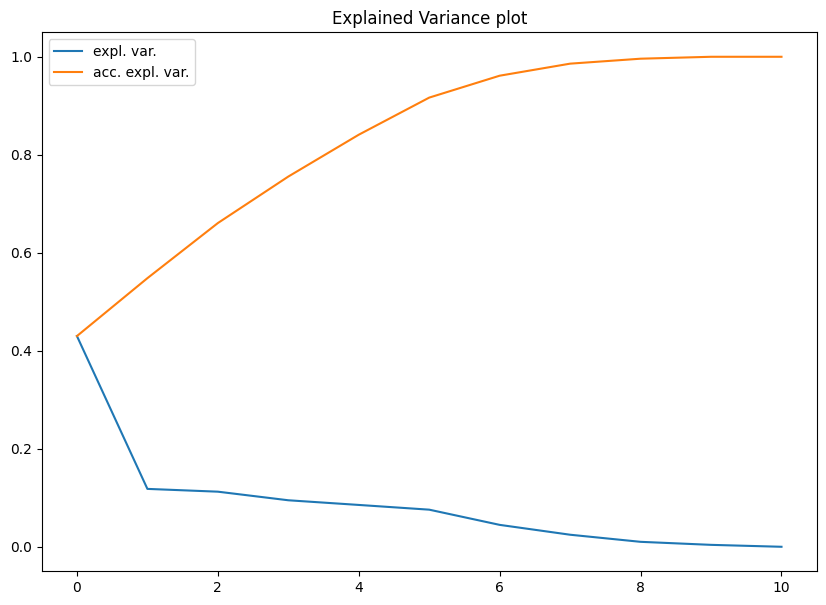

In [130]:
# visualizing explained variance to make an informed decision on threshold for reduction
expl_var=model_full.explained_variance_ratio_
plt.figure(figsize=(10, 7))
plt.plot(expl_var, label="expl. var.")
plt.plot(np.add.accumulate(expl_var), label="acc. expl. var.")
plt.legend()
plt.title("Explained Variance plot")
plt.show()

Reasoning: Based on the above visualization, I am choosing to keep the features that together accumulate at least 90% of the variance, since in the explained variance diagram, the curve of the accumulated explained variance is flattening around that point. Up until around 90% the line is going up quickly, but after that it is flattening out, meaning that the following features only contribute slightly to the variance. Therefore, 90% seems to be a reasonable cut off point for me, as it finds a balance between reducing dimensionality and retaining enough information. As a result, the pca dataset has only 6 features left, meaning it was reduced by 5 features. This shows that even when keeping 90% of variance, the dimensions were reduced significantly.

In [131]:
# applying chosen percentage of variance to retain
model = PCA(n_components=0.9) 

results = model.fit_transform(scaled_data)
print(results.shape)
# transforming into dataframe
data_pca=pd.DataFrame(results, index=data_full.index)
data_pca.round(2)

(400, 6)


,0,1,2,3,4,5
0,-1.52,1.63,-0.74,-0.27,0.99,-1.10
1,3.34,-1.05,-1.89,-0.96,-0.51,-0.37
2,-1.34,-0.76,0.24,0.44,-0.78,-0.49
3,-2.43,-1.21,-0.77,0.74,-1.87,-0.94
4,-2.85,0.33,-0.02,0.13,0.39,0.98
...,...,...,...,...,...,...
395,2.18,1.00,0.64,0.55,2.08,-0.00
396,-1.64,1.49,1.28,-1.94,1.35,0.17
397,-0.25,0.62,0.08,1.91,0.25,-0.03
398,1.47,0.13,1.80,0.15,-0.17,-0.36


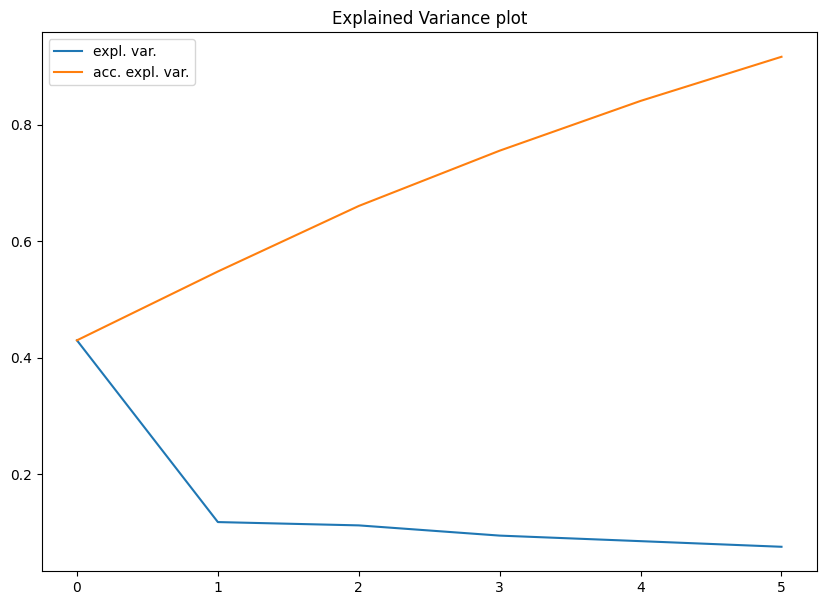

In [132]:
# Explained variance plot on reduced dataset 
expl_var=model.explained_variance_ratio_
plt.figure(figsize=(10, 7))
plt.plot(expl_var, label='expl. var.')
plt.plot(np.add.accumulate(expl_var), label='acc. expl. var.')
plt.title("Explained Variance plot")
plt.legend()
plt.show()

Observation: This again shows that the accumulated explained variance for the first 6 features only has a slight flattening after the first feature, which, as can be seen in the explained variance line, is responsible for over 40% of variance in the dataset. After that, the accumulated line is again almost a linear increase. Therefore, I am continuing with mmy choice of keeping all features that retain at least 90% of the variance. 

In [133]:
# Looking at the resulting dataframe
data_pca

,0,1,2,3,4,5
0,-1.516088,1.633153,-0.742973,-0.267694,0.992134,-1.096053
1,3.335179,-1.046002,-1.887513,-0.960593,-0.514111,-0.368210
2,-1.340107,-0.761850,0.240498,0.437206,-0.776821,-0.485198
3,-2.432252,-1.213348,-0.766600,0.743020,-1.865696,-0.941303
4,-2.851507,0.325344,-0.022223,0.134638,0.394718,0.982382
...,...,...,...,...,...,...
395,2.183963,1.002397,0.642337,0.554746,2.083680,-0.002405
396,-1.640048,1.494806,1.284010,-1.944436,1.345379,0.172282
397,-0.250051,0.620777,0.078586,1.910466,0.252167,-0.029004
398,1.471060,0.131464,1.800757,0.152451,-0.167126,-0.362568


## Task 6 – Dimensionality Reduction by Feature Selection

In [134]:
# Remembering what data_full looks like, as it is the starting point for this step
data_full

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,33,10.79,5.44,5.35,6.63,1,9.3,44.7,0.7,9.3,2.12
1,28,7.40,0.37,7.03,8.05,3,5.7,78.0,2.1,56.2,1.23
2,35,9.78,1.09,8.69,6.48,1,9.1,51.8,8.0,3.6,1.12
3,42,11.13,0.56,10.57,6.89,1,10.0,37.0,5.7,0.0,0.00
4,28,13.22,4.09,9.13,5.79,1,10.0,38.5,10.1,0.0,2.38
...,...,...,...,...,...,...,...,...,...,...,...
395,26,6.43,2.99,3.44,7.75,1,5.9,64.6,7.6,39.3,4.20
396,16,9.59,5.44,4.15,5.57,1,10.0,47.4,7.0,3.5,1.65
397,40,8.72,2.36,6.36,7.56,1,9.4,57.3,10.1,6.6,3.22
398,29,5.04,0.94,4.10,7.32,1,7.1,63.6,12.1,21.0,1.62


In [135]:
# Using MinMaxScaler to preserve variance but scale the data 
scaler = MinMaxScaler()

scaled_data = scaler.fit_transform(data_full)
# transforming into dataframe
scaled_data = pd.DataFrame(scaled_data, columns=data_full.columns)
scaled_data.head()

,age,screen_time_hours,work_screen_hours,leisure_screen_hours,sleep_hours,sleep_quality_1_5,stress_level_0_10,productivity_0_100,social_hours_per_week,mental_wellness_index_0_100,exercise_hours_per_week
0,0.386364,0.538800,0.446773,0.357945,0.390196,0.000000,0.93,0.303526,0.029289,0.095876,0.341935
1,0.272727,0.352229,0.021794,0.492777,0.668627,0.666667,0.57,0.722922,0.087866,0.579381,0.198387
2,0.431818,0.483214,0.082146,0.626003,0.360784,0.000000,0.91,0.392947,0.334728,0.037113,0.180645
3,0.590909,0.557512,0.037720,0.776886,0.441176,0.000000,1.00,0.206549,0.238494,0.000000,0.000000
4,0.272727,0.672537,0.333613,0.661316,0.225490,0.000000,1.00,0.225441,0.422594,0.000000,0.383871


Reasoning: Since in this step, reduction will be done based on variance, I have chosen a Scaler that does not equalize the variance.

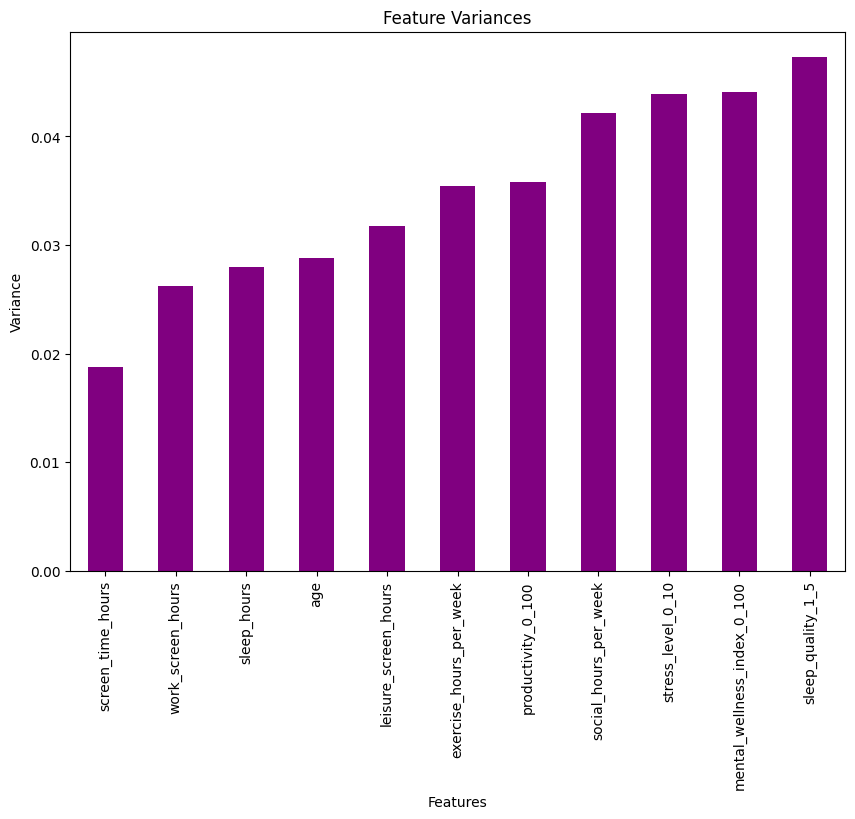

In [136]:
# Visualizing the variance across the features of the scaled data for an informed decision on threshold for reduction
variances = scaled_data.var()
variances.sort_values().plot(kind='bar', figsize=(10,7), color="purple")
plt.xlabel("Features")
plt.ylabel("Variance")
plt.title("Feature Variances")
plt.show()

Reasoning: The 4 features with the highest variance all have a variance above 0.04.  This is because in the above plot, a clear step can be seen between the fourth highest feature, social hours per week and the fifth highest variance feature, productivity_0_100. As the MinMaxScaler makes the variance comparable, I have chose to use that clear cut in my visualization as threshold for the dimensionality reduction by feature selection. All other features are below 0.04 and I have decided that is too little variance. My decision was therefore mainly based on the clear step in the graph, the numbers and the fact that 4 features still is significant enough and I think will retain enough information, while the variance threshold still reduces dimensionality significantly.

In [137]:
# Doing Feature reduction with variance threshold
variances = scaled_data.var()

# sorting the variances in descending order
sorted_vars = variances.sort_values(ascending=False)

#Choosing the 4 featues with the most variance
threshold = sorted_vars.iloc[4]

selector = VarianceThreshold(threshold=threshold)
reduced_data = selector.fit_transform(scaled_data)

# making lists to see which features were kept and discarded
kept_mask = selector.get_support()
kept_features = data_full.columns[kept_mask].tolist()
discarded_features = data_full.columns[~kept_mask].tolist()

# Looking at which features were kept and discarded
print("Kept:", kept_features)
print("Discarded:", discarded_features)

Kept: ['sleep_quality_1_5', 'stress_level_0_10', 'social_hours_per_week', 'mental_wellness_index_0_100']
Discarded: ['age', 'screen_time_hours', 'work_screen_hours', 'leisure_screen_hours', 'sleep_hours', 'productivity_0_100', 'exercise_hours_per_week']


In [138]:
# What reduced data looks like now 
reduced_data

array([[0.        , 0.93      , 0.0292887 , 0.09587629],
       [0.66666667, 0.57      , 0.08786611, 0.57938144],
       [0.        , 0.91      , 0.33472803, 0.0371134 ],
       ...,
       [0.        , 0.94      , 0.42259414, 0.06804124],
       [0.        , 0.71      , 0.50627615, 0.21649485],
       [0.        , 1.        , 0.41004184, 0.08659794]], shape=(400, 4))

In [139]:
# Transforming reduced data into a dataframe to visualize; renaming to final name
data_vt=pd.DataFrame(reduced_data, index=data_full.index, columns=kept_features)

In [140]:
# Final data_vt dataframe after dimensionality reduction with feature selection
data_vt

,sleep_quality_1_5,stress_level_0_10,social_hours_per_week,mental_wellness_index_0_100
0,0.000000,0.93,0.029289,0.095876
1,0.666667,0.57,0.087866,0.579381
2,0.000000,0.91,0.334728,0.037113
3,0.000000,1.00,0.238494,0.000000
4,0.000000,1.00,0.422594,0.000000
...,...,...,...,...
395,0.000000,0.59,0.317992,0.405155
396,0.000000,1.00,0.292887,0.036082
397,0.000000,0.94,0.422594,0.068041
398,0.000000,0.71,0.506276,0.216495


Observation: After applying dimensionality reduction with feature selection, 4 features are left in the dataframe, which will be used for the clustering experiments. 

## Task 7 – Exploratory Data Analysis: Clustering

### a) 𝑘-Means/𝑘-Means++

I have chosen the default init for kmeans, which is k-Means++. I am choosing this because of the advantagees k-Means++ provides, as it can lead to centroids that are farther apart and therefore avoid overlap. This is because it places centroids based on distances instead of at random.

**Dataset: data_full**

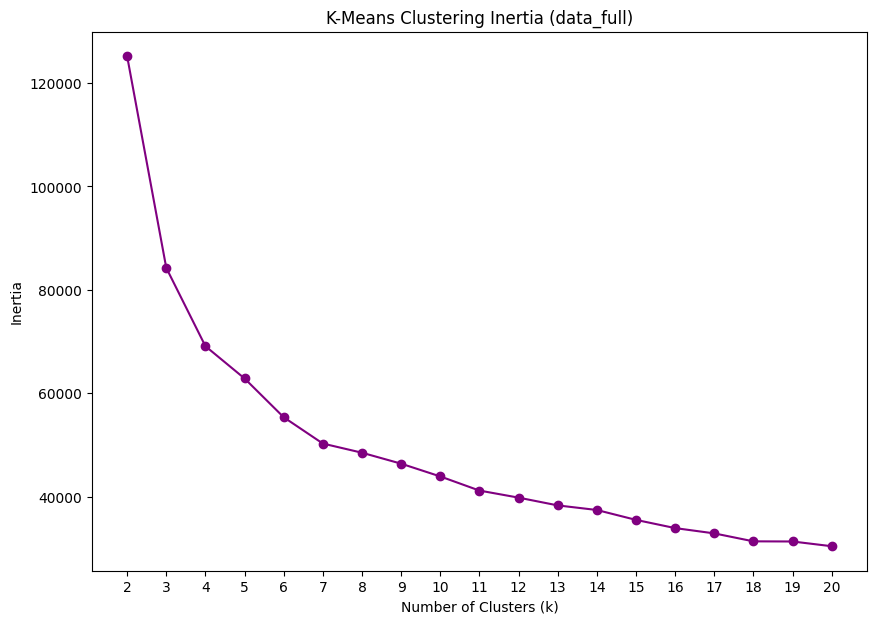

In [141]:
# Elbow method on inertia to determine number of clusters 
inertia = []
k_values = range(2, 21)

# Iterating over k values
for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_full)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 7))
plt.plot(k_values, inertia, marker="o", color = "purple")
plt.title("K-Means Clustering Inertia (data_full)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

Observation: The Inertia is very high for two clusters and decreases rapidly after that. At around seven clusters, thee curve starts to flatten out a little, but the decrease is still quite rapid. This could be an indication for seven clusters, as it is where the elbow in the graph is. But since inertia is not enough to make an informed decision, the next step is to plot the silhouette score. 

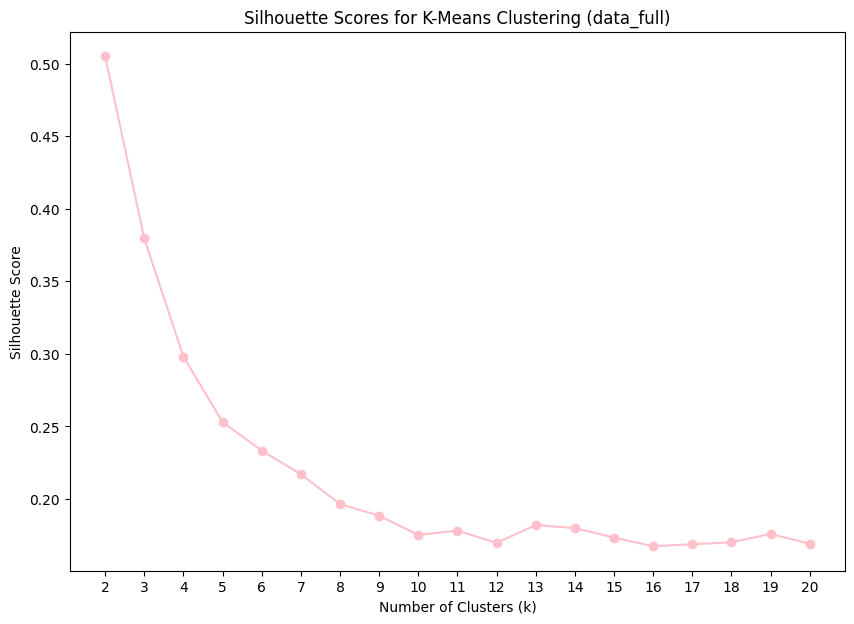

In [142]:
# plotting silhouette scores to derive k value
silhouette_scores = []
k_values = range(2, 21) # choosing a wide range to not miss a sensible k choice 

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42) # setting a random state to make results reproducable 
    labels = kmeans.fit_predict(data_full)
    score = silhouette_score(data_full, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 7))
plt.plot(k_values, silhouette_scores, marker="o", color="pink")
plt.title("Silhouette Scores for K-Means Clustering (data_full)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

Observation: For k=2, the silhouette score is a little above 0.5, probably around 0.51 or 0.52. After that it decreases rapidly, with k=3 only resulting in a score of about 0.38. At k=5 and a score of around 0.26, the curve starts to flatten out a little, with a few minor ups and dows after k=10.

Interpretation: 2 clusters yield the by far best silhouette score and the only score than can be counted as okay. Everything below does not show clear and distinct clusters. And even with the 2 clusters, some overlap might be present, as it is still a fairly low value, since the Silhouette score can go up to 1. Comparing this to the inertia, the Silhouette score yields a very different result. But since it it a more telling determinator about clear cluster separation, I will go with the Silhouette Score and choose k=2 for the further k-means clustering.

In [143]:
# Numpy array transformation for further analysis 
data_full_np = np.array(data_full) 

In [144]:
k = 2 # Chosen from Silhouette Score

kmeans = KMeans(n_clusters=k, random_state=42) # random state for reproducability
labels = kmeans.fit_predict(data_full_np)
centers = kmeans.cluster_centers_

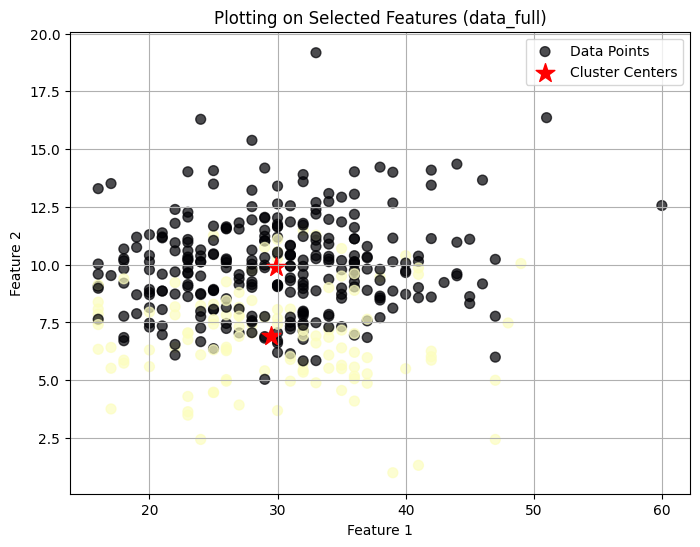

In [145]:
# Plotting first two features to get a feeling for the clusters; only exemplary
plt.figure(figsize=(8, 6))

plt.scatter(data_full_np[:, 0], data_full_np[:, 1], c=labels, cmap="magma", alpha = 0.7,s=50, label="Data Points")
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="*", label="Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Plotting on Selected Features (data_full)")
plt.legend()
plt.grid(True)
plt.show()

Observation: The above scatterplot only shows the first two features and their clusters. As this only shows 2D space, it is not fully interpretable, as points can be more or less overlapping in more dimensional space. Additionally, this does not tell anything about other features. At the same time, it is a tool for getting a feeling of how the data might be clustered, which is why I have included the visualization in my experiments. 

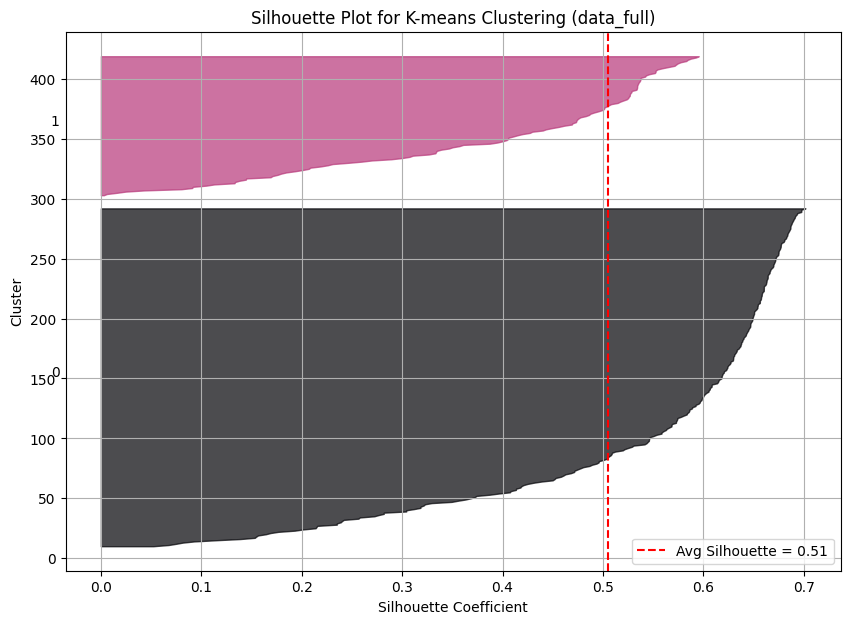

In [146]:
# plotting the Silhouette Coefficient
silhouette_vals = silhouette_samples(data_full_np, labels)
avg_score = silhouette_score(data_full_np, labels)

plt.figure(figsize=(10, 7))
y_lower = 10
for i in range(k):
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()

    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.magma(float(i) / k) 
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)

    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg Silhouette = {avg_score:.2f}") # line for average score 
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for K-means Clustering (data_full)")
plt.legend()
plt.grid(True)
plt.show()


Interpretation: The above Silhouette Coefficient plot shows that a lot of values are in cluster 0. Furthermore, the average silhouette score is 0.51, which is mediocre (not too good) but not too bad. The shape of the plots show that especially the 0 cluster has quite a lot of values with low score, which indicates overlap. Therefore, the exemplary scatterplot seems to be a quite good visualization of how the clusters might be overlapping, as indicated by the Silhouette plot. In the end, k-means clustering on the full dataset has resultet in two clusters that show some overlap. It is not a very good result, but decent enough to not be discared completely.

**Dataset: data_pca**

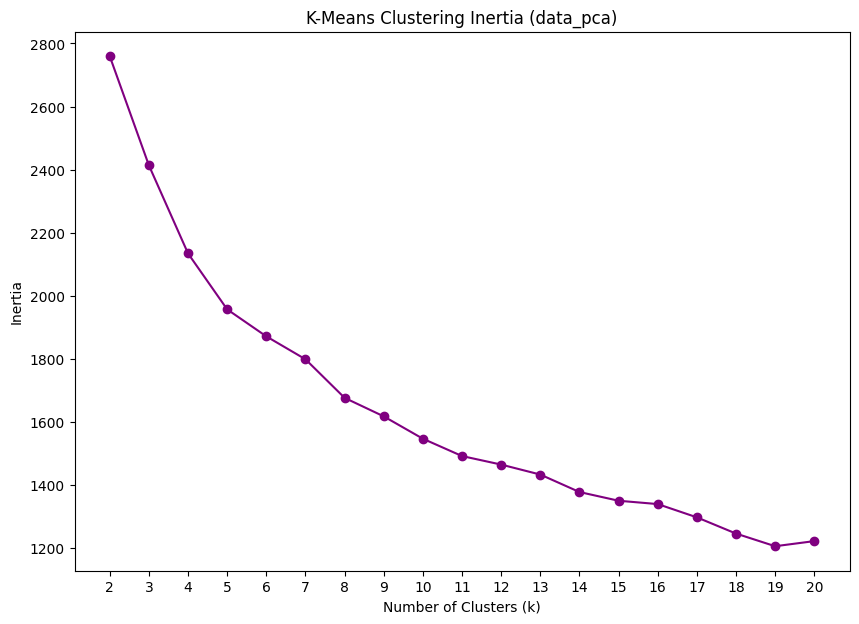

In [147]:
# Plotting the elbow of inertia for pca data
inertia = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_pca)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 7))
plt.plot(k_values, inertia, marker="o", color = "purple")
plt.title("K-Means Clustering Inertia (data_pca)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()

Observation: Overall, the inertia is much smaller for the pca data compared to the full data. Furthermore, the elbow is less visible in the line. This time it seems to sit at around k=5. This could be an indication for five clusters, as it is where the elbow in the graph is. But the curve does not flatten out as quickly after that, compared to the full dataset. Furthermore, there is a second dip at k=8, which looks a little like a second elbow. But since inertia is not enough to make an informed decision, the next step is to plot the silhouette score. 

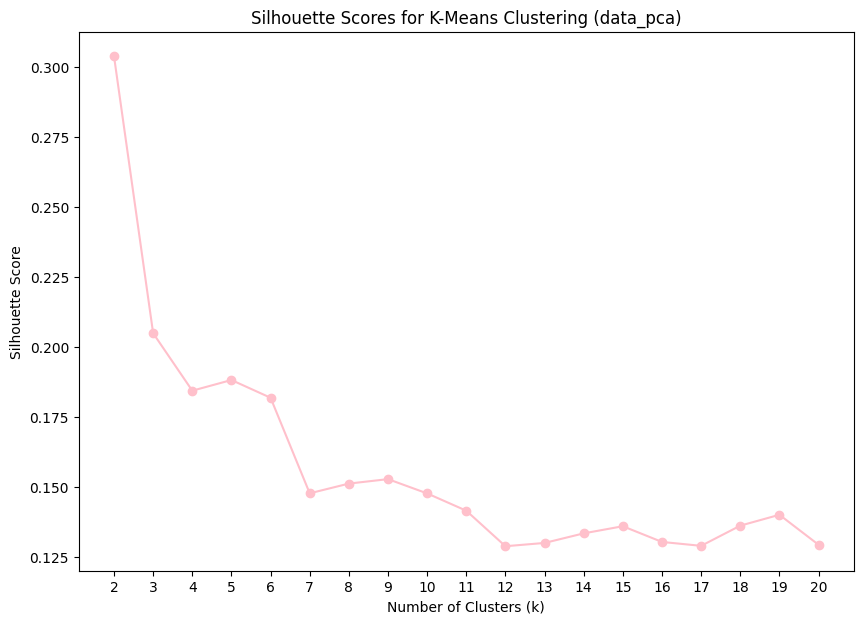

In [148]:
# Plotting Silhouette Scores for pca data to derive meaningful k 
silhouette_scores = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(data_pca)
    score = silhouette_score(data_pca, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 7))
plt.plot(k_values, silhouette_scores, marker="o", color="pink")
plt.title("Silhouette Scores for K-Means Clustering (data_pca)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

Observation: As with the full dataset, the k=2 yields the highest silhouette score, this time at around 0.31. After that it decreases rapidly, with k=3 only resulting in a score of about 0.21. After k=4 there are some ups and downs in the line. But none of the ups reach a score close to 0.3 like k=2.

Interpretation: 2 clusters yield the by far best silhouette score but at 0.31 it is still very low. Everything below that shows even less clear or distinct clusters. This plot already suggests, that k-means clustering on the pca dataset does not yield any usable results.
Comparing this to the inertia, the Silhouette score yields a very different result. But since it it a more telling determinator about clear cluster separation, I will go with the Silhouette Score and choose k=2 for the further k-means clustering.

In [149]:
# Numpy array needed for further steps
data_pca_np = np.array(data_pca)

In [150]:
k = 2 # Chosen from the Silhouette Score 

kmeans = KMeans(n_clusters=k, random_state=42) # random state for reproducability
labels = kmeans.fit_predict(data_pca)
centers = kmeans.cluster_centers_

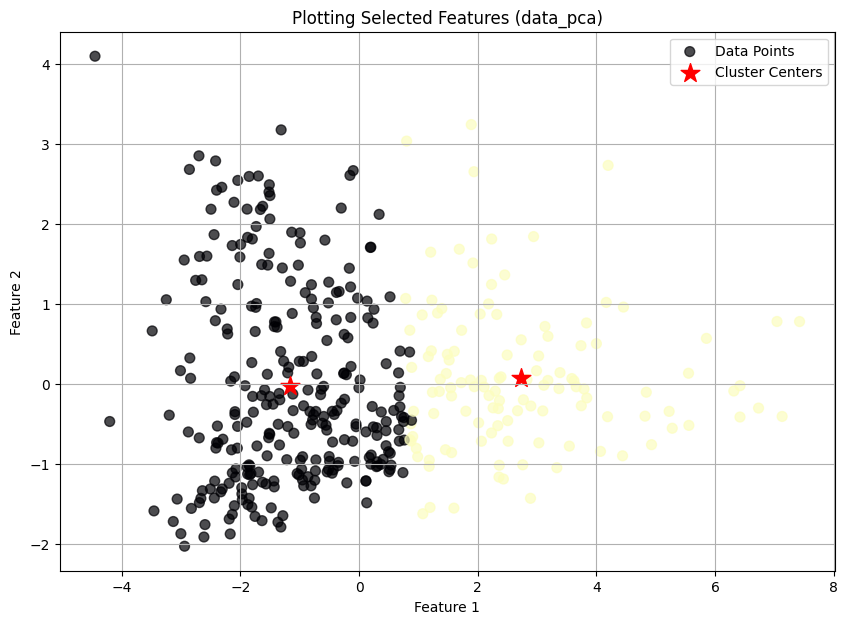

In [151]:
# Visualize first two features, only exemplary, real data has more dimensions
plt.figure(figsize=(10, 7))
plt.scatter(data_pca_np[:, 0], data_pca_np[:, 1], c=labels, cmap="magma", s=50, alpha=0.7, label="Data Points")
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="*", label="Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Plotting Selected Features (data_pca)")
plt.legend()
plt.grid(True)
plt.show()

Observation: As with the full data, the above scatterplot only shows the first two features and their clusters. As this only shows 2D space, it is not fully interpretable, as points can be more or less overlapping in more dimensional space. Additionally, this does not tell anything about other features. In this case for example, the plot shows two quite well seperated clusters right next to each other. At first glance, it looks better than the plot resulting from the full dataset. But the Silhouette Score suggests a different result. This shows that these scatterplots can be misleading, if not used carefully. Therefore, they are only one small tool in evaluating the clustering methods and should not be the basis for interpretation. 

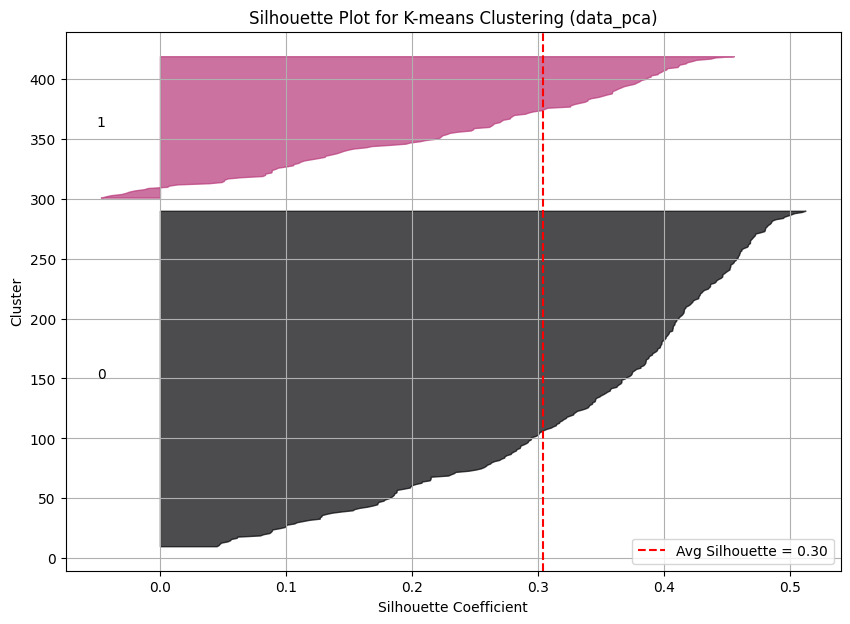

In [152]:
# Silhouette Plot for data_pca
silhouette_vals = silhouette_samples(data_pca, labels)
avg_score = silhouette_score(data_pca, labels)

plt.figure(figsize=(10, 7))
y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i

    color = plt.cm.magma(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10

plt.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg Silhouette = {avg_score:.2f}") # visualize average score
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for K-means Clustering (data_pca)")
plt.legend()
plt.grid(True)
plt.show()


Interpretation: A lot of data points are in cluster 0. Furthermore, a lot of them range in low silhouette score areas. This shows that the clusters most likely are not very distinct and have a lot of uncertainty and overlap. Furthermore, the average Silhouette Score is 0.3, which also means that the Clusters are not clear. Additionally, there are some data points with negative Silhouette Scores in Cluster one, meaning that they might even be in the wrong cluster, which again indicates, that it was not possible to form clear, distinct clusters in this step. In total, the k-means clustering on pca-data did not yield good clusterings and should not be the chosen method for the project. Either a different clustering method or a different form of the dataset are needed.

**Dataset: data_vt**

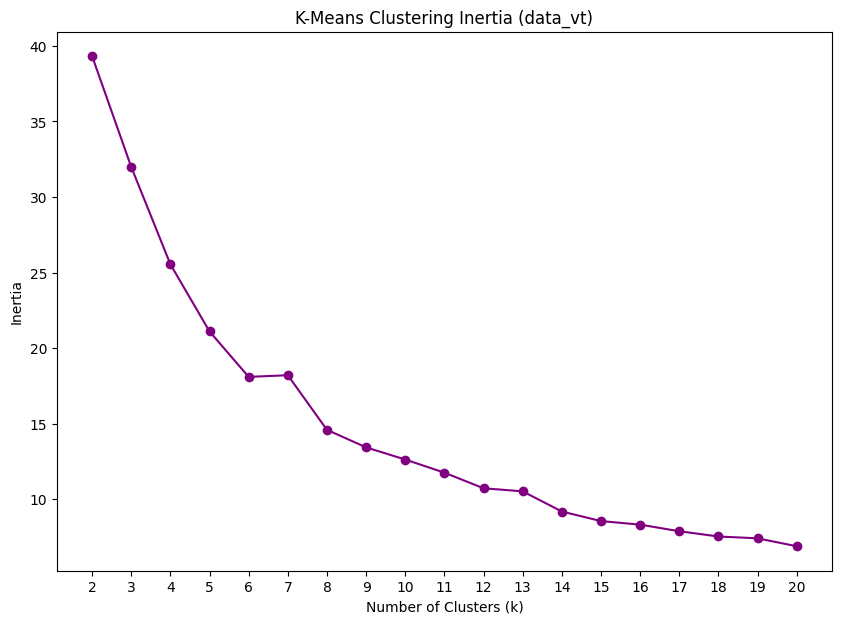

In [153]:
# Inertia elbow on vt data
inertia = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(data_vt)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(10, 7))
plt.plot(k_values, inertia, marker="o", color = "purple")
plt.title("K-Means Clustering Inertia (data_vt)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.show()


Observation: Compared to the pca dataset, the inertia is again much smaller on the vt data. As data_vt only has 4 features left, this seems logical. This time, the elbow can be found at k=6, which could indicate six clusters. But after that, for k=7, the line goes up a little before going down again, creating a second elbow at k=8. Down the line there are a few more dips that could be interpreted as elbows but they are too small to indicate a different k based on inertia. As with the other two datasets, a Silhouette Score will be used to further analyse which k to use for the clustering.

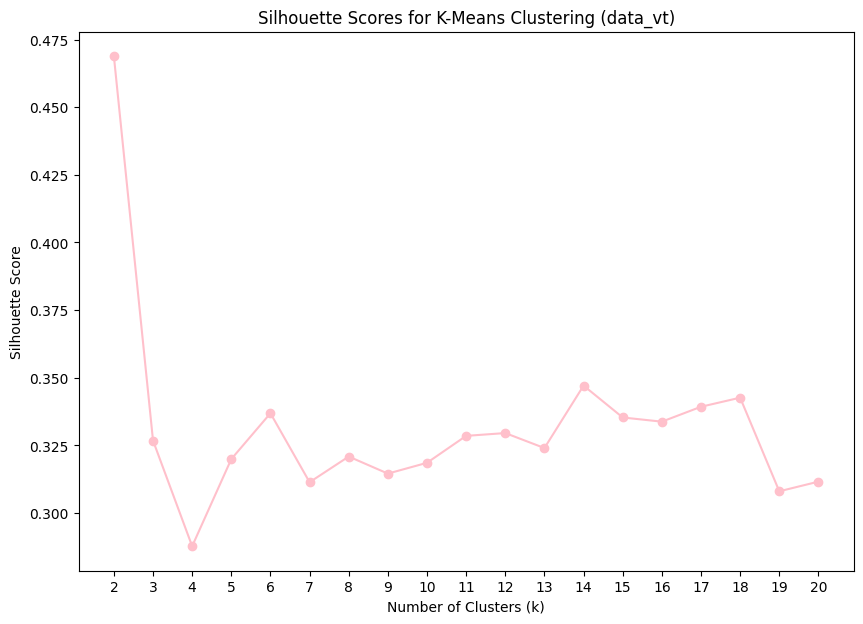

In [154]:
# Silhouette Scores for data_vt
silhouette_scores = []
k_values = range(2, 21)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=1)
    labels = kmeans.fit_predict(data_vt)
    score = silhouette_score(data_vt, labels)
    silhouette_scores.append(score)

plt.figure(figsize=(10, 7))
plt.plot(k_values, silhouette_scores, marker="o", color="pink")
plt.title("Silhouette Scores for K-Means Clustering (data_vt)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(k_values)
plt.show()

Observation: As with the full dataset and pca dataset, the k=2 yields the highest silhouette score, this time at around 0.47, which is better than the score for the pca dataset, but still below 0.5, which suggests less than moderately well seperated clusters. Furthermore, there is a lot more up and down in the line after k=3, with the second highest Silhouette Score appearing for k=14 with a score of about 0.36. 

Interpretation: One again k=2 suggests itself the most, based on the Silhouette Score. With 0.47, it is decent but still below 0.5, so close to being okay but still not very good. Therefore, this version does not yield very good results.

In [155]:
# numpy array for further analysis
data_vt_np = np.array(data_vt)

In [156]:
k = 2 # chosen based on Silhouette score

kmeans = KMeans(n_clusters=k, random_state=42) # random state for reproducability
labels = kmeans.fit_predict(data_vt)
centers = kmeans.cluster_centers_

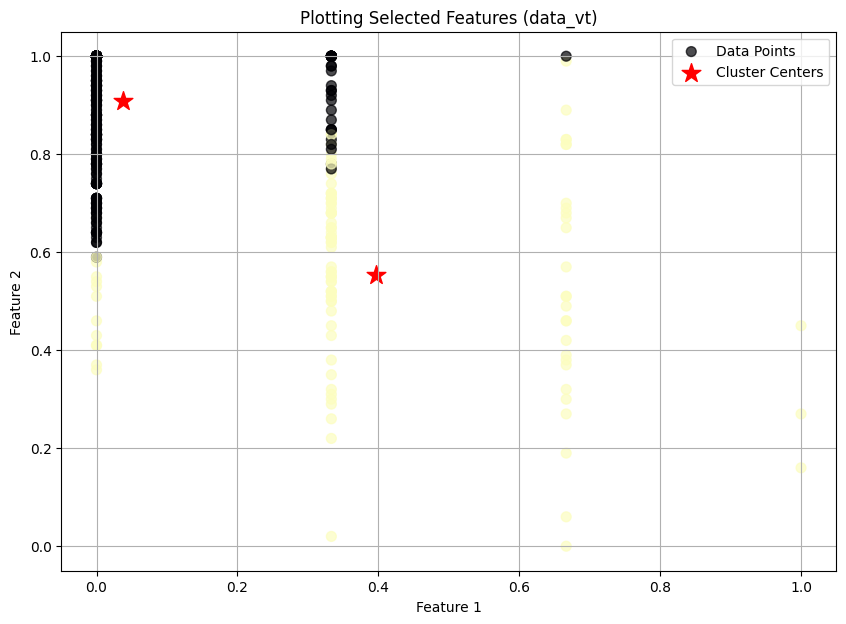

In [157]:
# Visualization of exemplary features; full data has more dimensions
plt.figure(figsize=(10, 7))
plt.scatter(data_vt_np[:, 0], data_vt_np[:, 1], c=labels, cmap="magma", s=50, alpha=0.7, label="Data Points")
plt.scatter(centers[:, 0], centers[:, 1], c="red", s=200, marker="*", label="Cluster Centers")
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title(f"Plotting Selected Features (data_vt)")
plt.legend()
plt.grid(True)
plt.show()

Observation: The scatterplot visualizes two features as an example. Compared to the full data and the pca data, this plot looks very different. Instead of bundled clusters, these are more vertical. But there is only little overlap and the centers are further apart. As with the examples before, this does not lead to a full interpretation yet, as it is only indicative of what clusters might look like but there are more dimensions in the data, in which the clusters might actually look different with more or less overlap. At the same time, it does represent the Silhouette Score of about 0.47, as there kind of two distinct clusters, but there is still some overlap.

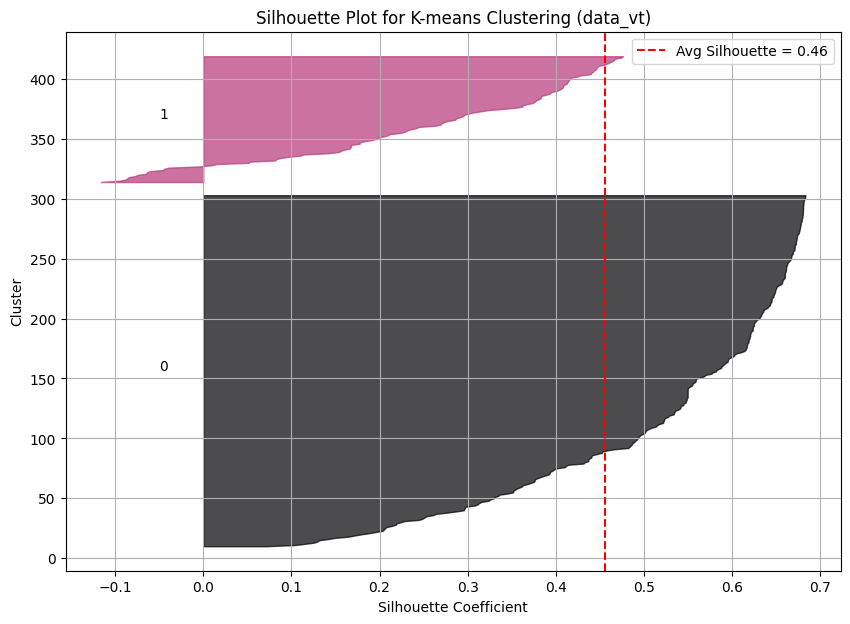

In [158]:
# Silhouette Plot for vt data 
silhouette_vals = silhouette_samples(data_vt, labels)
avg_score = silhouette_score(data_vt, labels)

plt.figure(figsize=(10, 7))
y_lower = 10

for i in range(k):
    ith_cluster_silhouette_values = silhouette_vals[labels == i]
    ith_cluster_silhouette_values.sort()
    size_cluster_i = ith_cluster_silhouette_values.shape[0]
    y_upper = y_lower + size_cluster_i
    color = plt.cm.magma(float(i) / k)
    plt.fill_betweenx(np.arange(y_lower, y_upper),
                      0, ith_cluster_silhouette_values,
                      facecolor=color, edgecolor=color, alpha=0.7)
    plt.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
    y_lower = y_upper + 10 

plt.axvline(x=avg_score, color="red", linestyle="--", label=f"Avg Silhouette = {avg_score:.2f}") # visualize average score 
plt.xlabel("Silhouette Coefficient")
plt.ylabel("Cluster")
plt.title("Silhouette Plot for K-means Clustering (data_vt)")
plt.legend()
plt.grid(True)
plt.show()


Interpretation: This is quite similar to data_pca. A lot of data points are in cluster 0. Furthermore, a lot of them range in low silhouette score areas. This shows that the clusters most likely have some uncertainty and overlap. Furthermore, the average Silhouette Score is 0.46, which also means that the Clusters have some overlap. Additionally, there are some data points with negative Silhouette Scores in Cluster one, meaning that they might even be in the wrong cluster, which again indicates, that it was not possible to form completely clear, distinct clusters in this step. Especially in cluster 1, most datapoints are also below the average, showing that the average is significantly influenced by cluster 0. In total, this means that there are clusters that are distinct to some extend, but there is quite some overlap and misclassification. Furthermore, the clusters are not very balanced. This indicates that k-means clustering on data_vt is probably not the best clustering approach for the project.

### b) OPTICS

I am using reachability distance diagrams as visual Representation in this step, which is readable even for very large datasets with high dimensionality as compared to the scatterplots with k-means. Furthermore, I am using the clustering method xi, which automatically asigns clusters. I am doing this, to explore the influence of some parameters. In the final, I will use my own, manual distance cuts on the parameters determined in these experiments.

**Dataset: data_full**

**Distance Function**

For the data_full dataset I have chosen the cosine distance function as my distance function for the OPTICS clustering. I have done this, because cosine does not take magnitudes into account as it only looks at directions, meaning that it is not as important for the data to be scaled. As my data_full is unscaled data, I have chosen cosine over Euclidean for example, as that is sensitive to magnitudes and scaling is needed. Furthermore, cosine represents relationships between data and can help recognize patterns, which is exactly what I am trying to do in my project. Additionally, cosine similarity works quite well with higher dimensional data and since data_full is not reduced in its dimensionality, this is another point in favor of cosine distance. 

**Experiments with parameters**

In the following I am experimenting with the parameters min_samples, xi and min_cluster_size and using the cluster_method "xi"

Explanations:

min_samples: minimum number of points in a neighborhood for a point to be considered as a core point 

xi: density threshold for creating new cluster; determining border of cluster

min_cluster_size: minimum of points for a cluster to be considered a cluster



[0]
Number of clusters: 1


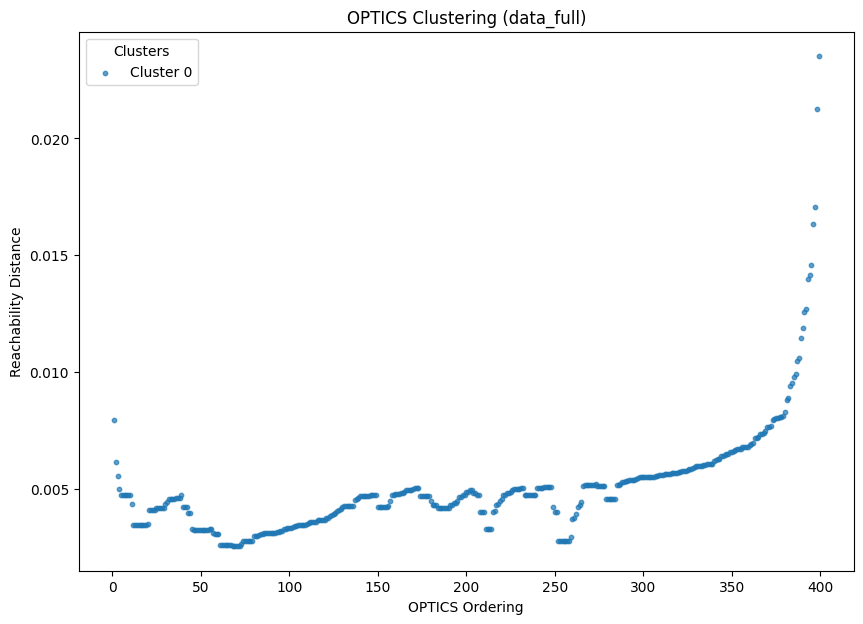

In [159]:
# choosing a starting point: 10 samples, 0.1 - clear borders, min_cluster_size 5% of data
# cosine distance function, reasons explained above
optics = OPTICS(min_samples=10, xi=0.1, min_cluster_size=0.05, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))

plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: In this case, OPTICS put all datapoint into one cluster. One reason for this could be, that there are no clearly defined density borders in my data. For the next experiment, I am therefore lowering the xi value.

[-1  0]
Number of clusters: 1


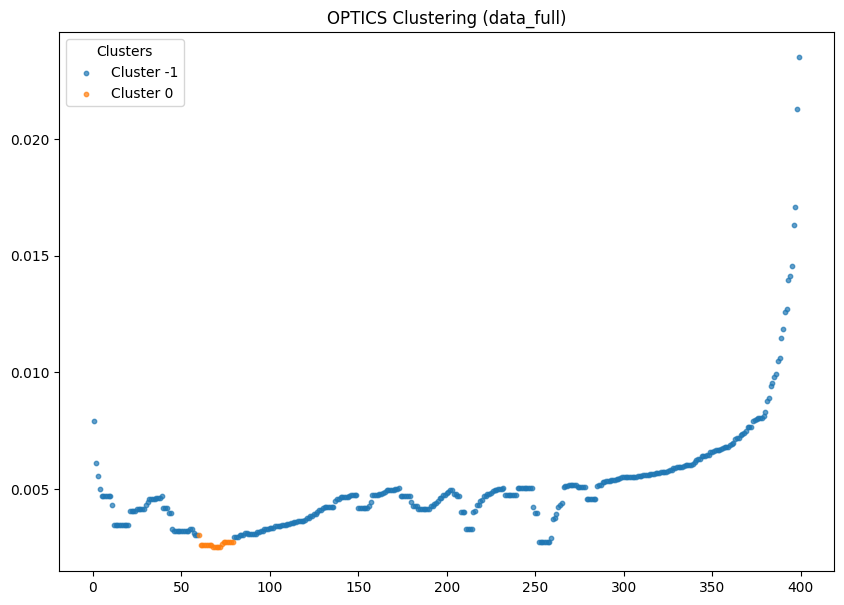

In [160]:
# adjusted parameters: 10 samples, 0.01 - less clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Now I have a cluster and, judging by the plot, a lot of noise, meaning some seperation happened,but not enough points around one core to form new clusters, which is why there is now noise. Therefore, I am adjusting min_cluster_size next.

[-1  0  1  2  3]
Number of clusters: 4


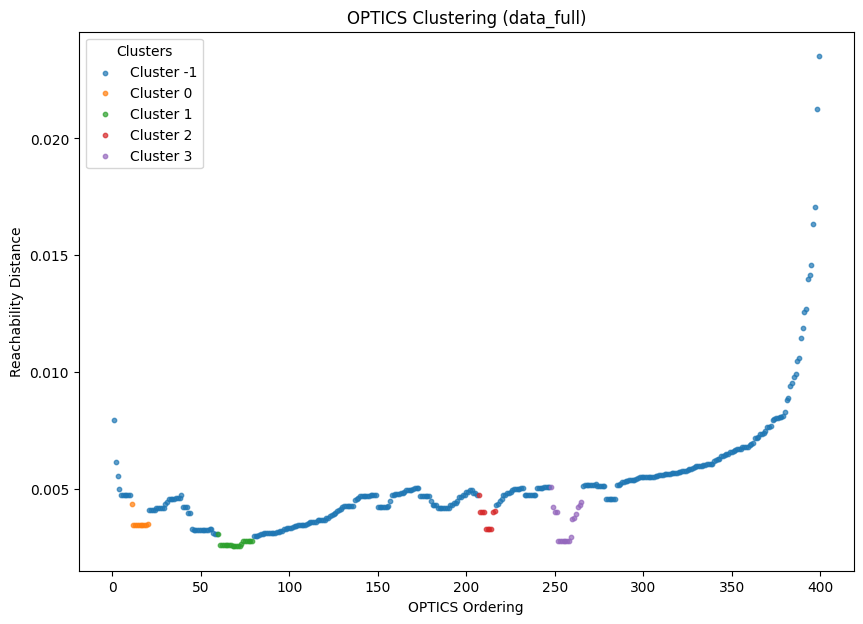

In [161]:
# adjusted parameters: 10 samples, 0.05 - more vague borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

[-1  0  1  2  3  4  5  6]
Number of clusters: 7


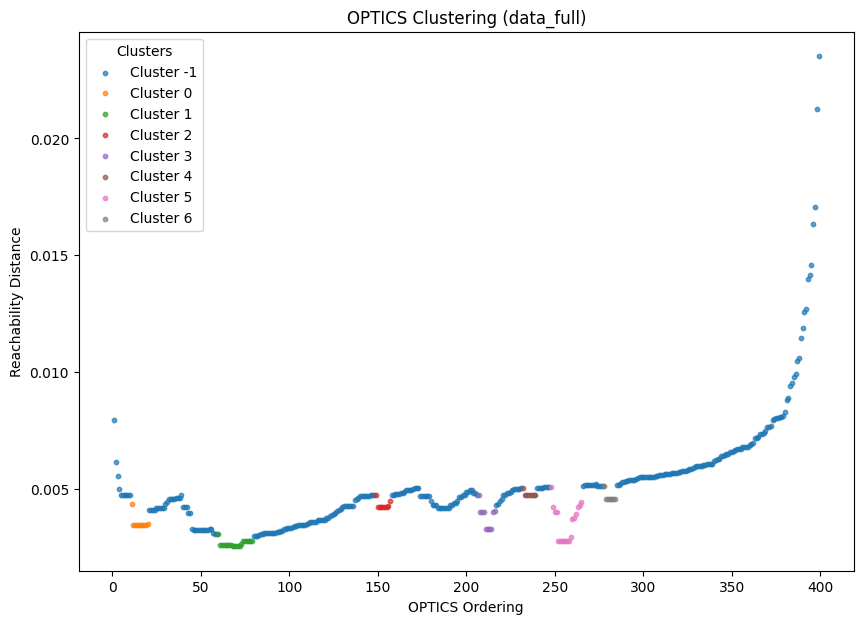

In [162]:
# adjusted parameters: 10 samples, 0.05 - more vague borders, min_cluster_size 1% of data
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.01, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Some smaller clusters can be formed when setting the min cluster size to 2.5% of the data. Now there are 4 clusters in the data. Even more clusters (7) form when only 1% of samples is required for a cluster. But as there are only 400 samples in the data, 1% is too small to make a sensical group for the purpose of my project. Therefore, I will continue experiments with min_cluster_size = 0.025. In both options, there is still a lot of noise. Still, this experiment shows the effect of a very low min_cluster_size on the clustering. I now want to see what happens when going up with the min_samples, making it again a little harder to form clusters as more points in the neighborhood are needed to form a core point.

[-1  0  1  2  3]
Number of clusters: 4


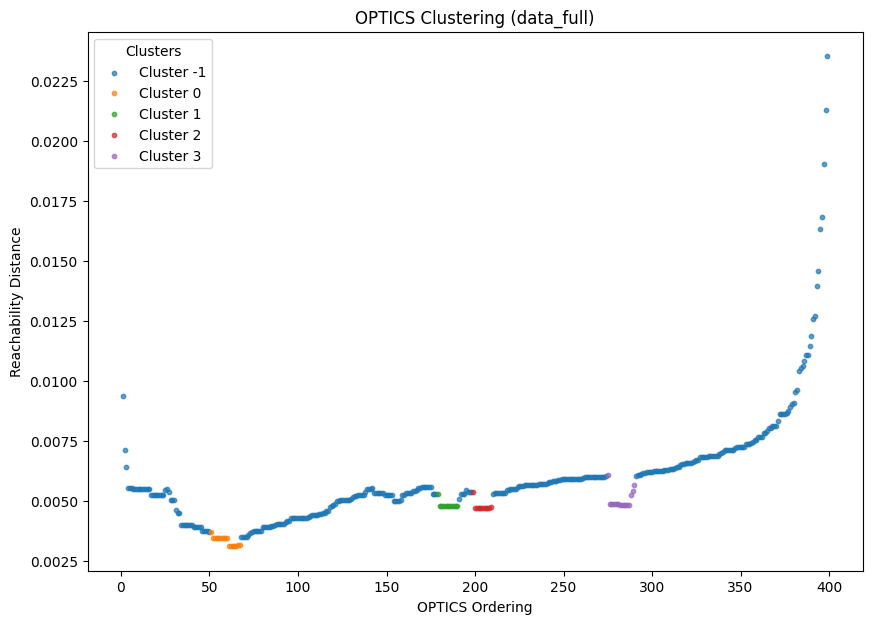

In [163]:
# adjusted parameters: 15 samples, 0.05 - more vague borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

[0]
Number of clusters: 1


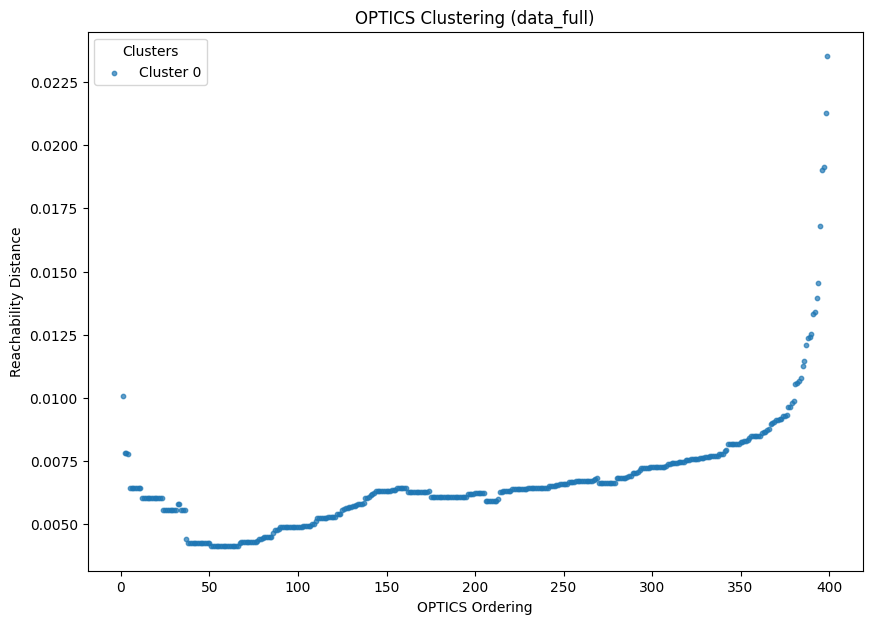

In [164]:
# adjusted parameters: 20 samples, 0.05 - more vague borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=20, xi=0.05, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: While increasing the min_samples to 15 does not change the number of clusters at this point, increasing to 20 changes the clustering drastically with again only one cluster appearing. Therefore, using min_samples = 20 seems to be too high. I will continue experiments with min_samples = 15 for now. 

[-1  0  1]
Number of clusters: 2


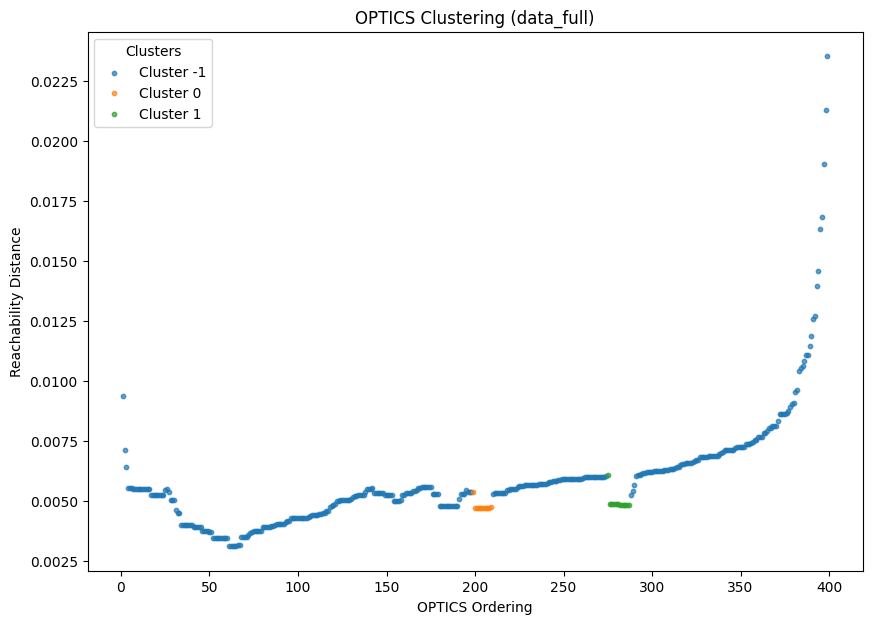

In [165]:
# adjusted parameters: 15 samples, 0.075 - increasing density borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.075, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: I am trying so slowly increase the xi value again, to get better defined clusters. For xi = 0.075, ther are two clusters left. This is only half compared to before. As xi = 0.1 resulted in only one clusters earlier, I will not increase it further. At the same time, min_cluster_size is stil fairly low, therefore I will try increasing it again next.

[-1  0]
Number of clusters: 1


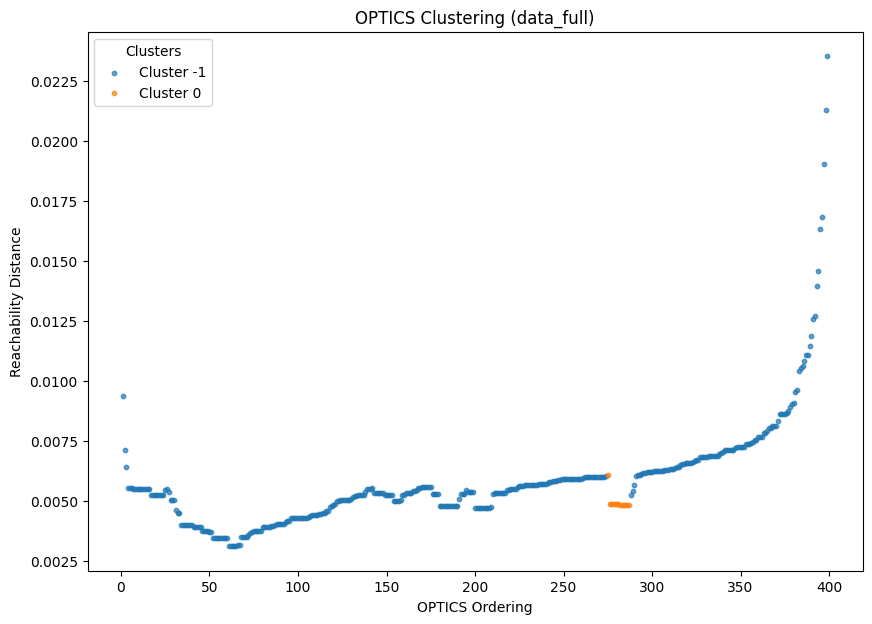

In [166]:
# adjusted parameters: 15 samples, 0.075 - increasing density borders, min_cluster_size 3% of data
optics = OPTICS(min_samples=15, xi=0.075, min_cluster_size=0.03, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: An increase to 3% of data for the minimum cluster size shows that only one cluster and noise are remaining. Therefore, this is probably not the way to go. I wil lower the xi value again, just to see how quickly new clusters form when lowering the density border. By doing this I also want to try assigning some of the noise points to clusters, as still most of my data is sorted into noise.

[-1  0  1  2  3]
Number of clusters: 4


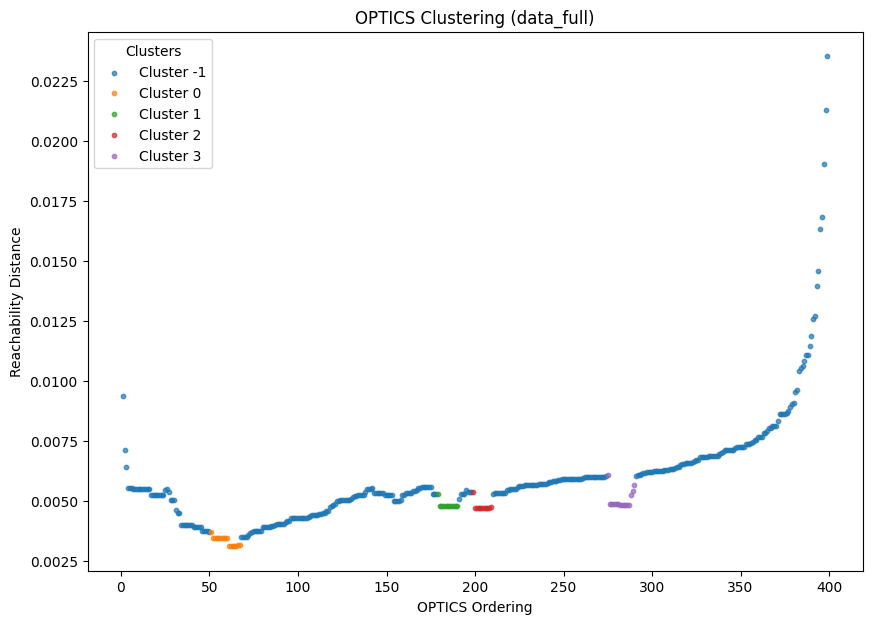

In [167]:
# adjusted parameters: 15 samples, 0.05 - lowering density borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.05, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

[-1  0  1  2  3  4]
Number of clusters: 5


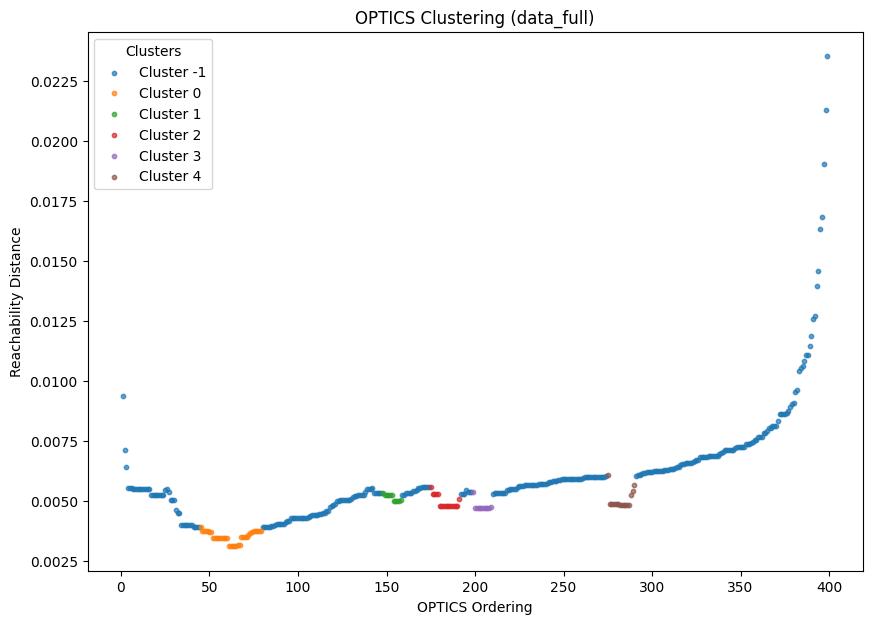

In [168]:
# adjusted parameters: 15 samples, 0.03 - lowering density borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.03, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

[-1  0  1  2  3  4]
Number of clusters: 5


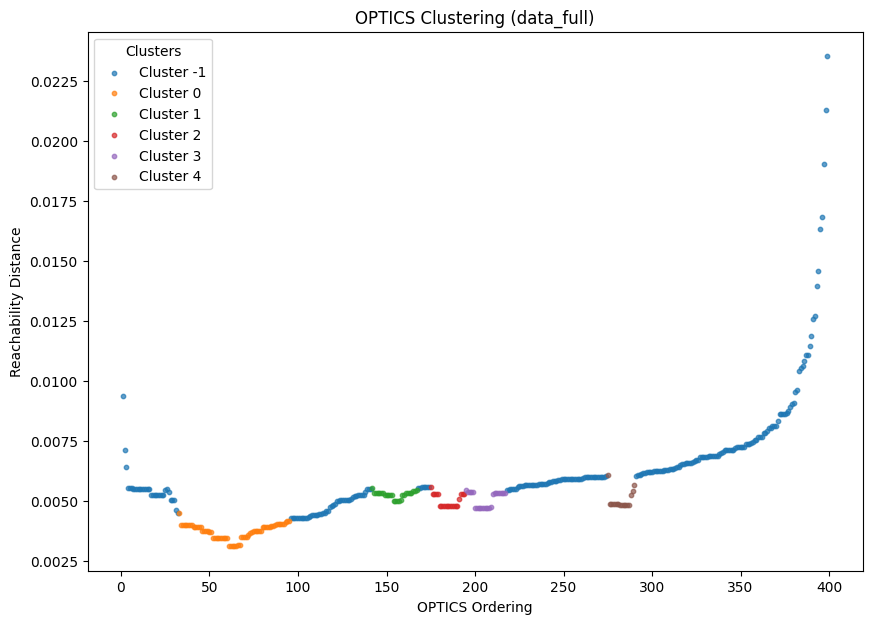

In [169]:
# adjusted parameters: 15 samples, 0.01 - lowering density borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.01, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

[-1  0  1  2  3  4  5]
Number of clusters: 6


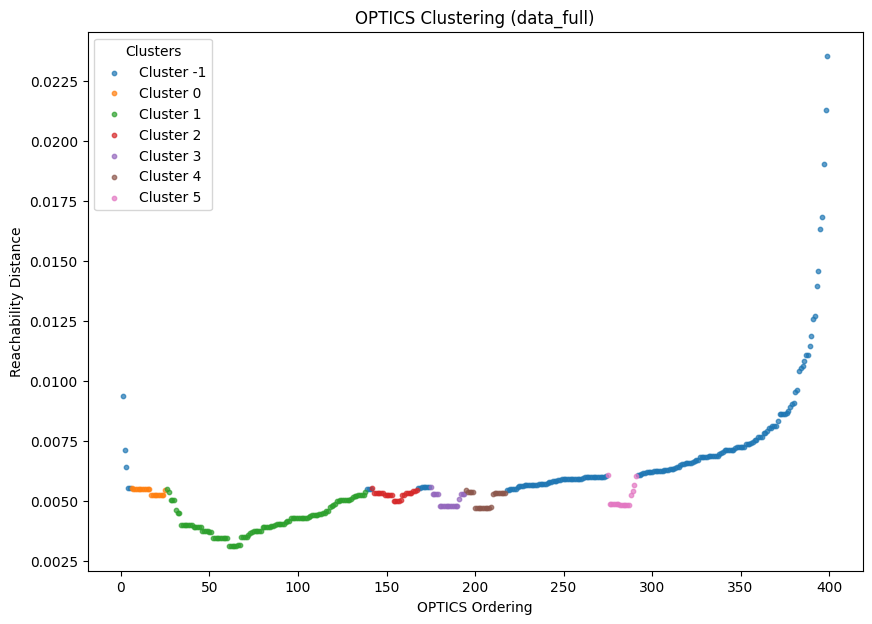

In [170]:
# adjusted parameters: 15 samples, 0.005 - lowering density borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=15, xi=0.005, min_cluster_size=0.025, metric="cosine")
optics_clusters=optics.fit_predict(data_full)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")


ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_full))
plt.figure(figsize=(10, 7))
for c in clusters:  # code for color per cluster adjusted by ChatGPT - copied code from other Source
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_full)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Lowering the xi value increases the number of clusters, but not as rapidly. Going from xi = 0.05 to xi = 0.005 increases the number of clusters from 4 to 6. At the same time, quite a lot of noise points are now being sorted into clusters. Therefore, some bigger clusters can be formed at the cost of the borders between clusters not being as defined.

**Final Evaluation**

The optics clustering experiments show that there are porbably some clusters in the data, but their differences are only small and there is some overlap, since increasing the xi value rapidly decreases the number of clusters. Therefore, the potential clusters are fairly small, as increasing the minimum cluster size also quickly reduces the number of clusters. Furthermore, there is a potential to make the clusters quite small, which would increase number of clusters, but since there are only 400 samples in my data, making the percentage of data samples to have to form a cluster too small leads to very specific, small groups which are not as useful for the project. 

Furthermore, the plots show no clear valleys which are usually expected when using OPTICS clustering. This means that the OPTICS clustering was not able to determinen precise clusters. Even experimenting with the parameters did not change that drastically. One reason for this could be choice of cosine for the distance function. On the other hand, it might be possible, that the data just does not provide good clusterings into user groups.

At the same time, for most parameter choices there is a lot of noise and only few samples actually get sorted into clusters. Only when lowering the xi value, noise points slowly start getting assigned to clusters, meaning there is probably a lot of overlap. 

**Dataset: data_pca**

**Distance Function**

For the data_pca dataset, I am choosing the Euclidean distance function. While I want to find similarities in user behaviour, I also do not want to fully disregard magnitudes of features. I think that it might still be important for identifying user groups with at risk behaviors for bad mental wellness scores to look at the numbers, meaning that it is not only important wether someone spends a lot of time at their screen but also wether it is 4 hours or 6. For the data_full dataset, the unscaled data and higher dimensionality then outweighed the consideration of including magnitudes but in the pca reduced data, the dimensions are lower and the data is scaled, eliminating those factors. Therefore, I am choosing euclidean as the distance function for the following experiments.

**Experiments with parameters**

In the following I am experimenting with the parameters min_samples, xi and min_cluster_size (explanations see above in section on data_full)

[0]
Number of clusters: 1


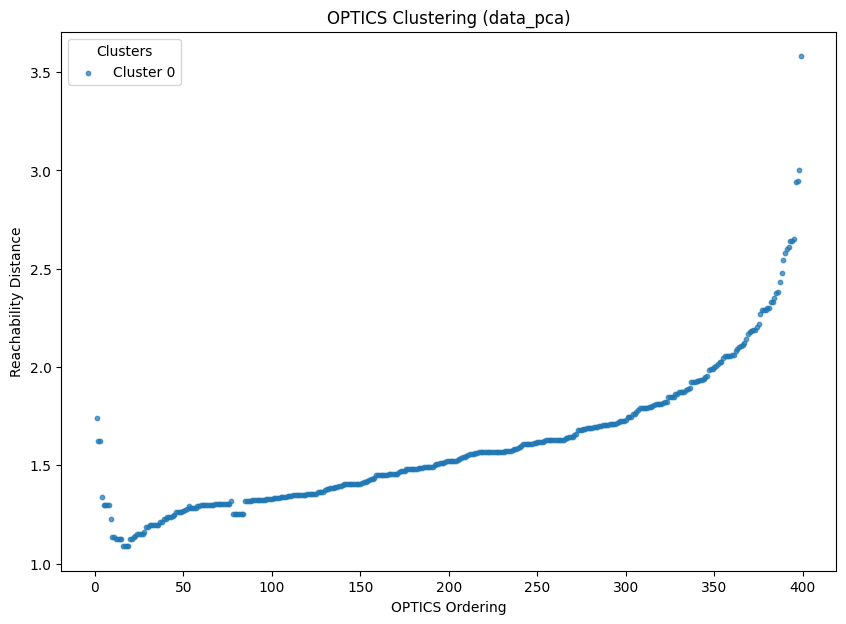

In [171]:
# same starting point: 10 samples, 0.1 - clear borders, min_cluster_size 5% of data
# distance metric: euclidean, explanation above
optics = OPTICS(min_samples=10, xi=0.1, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_pca)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Using the same starting point with a different distance function and reduced data still yields only one cluster. Again there is no noise and all samples were sorted into the one cluster. Therefore, I am trying to reduce xi again in the next step. 

[0]
Number of clusters: 1


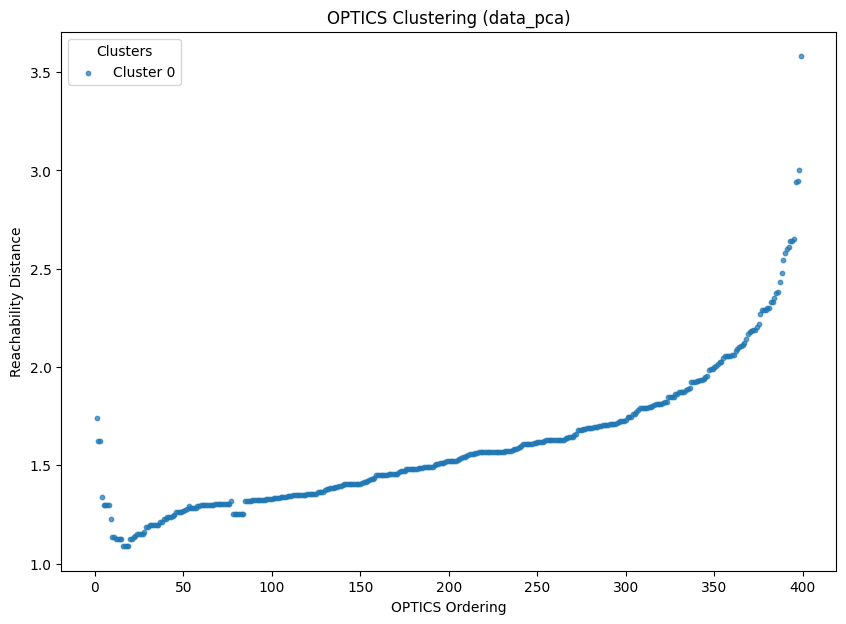

In [172]:
# adjusted parameters: 10 samples, 0.05 - less clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_pca)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.legend(title="Clusters")
plt.show()

[-1  0]
Number of clusters: 1


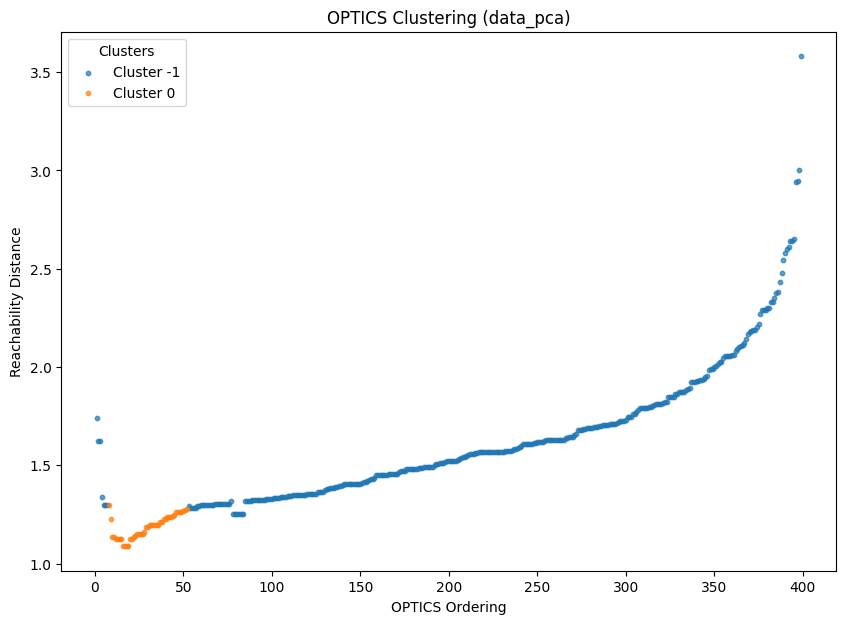

In [173]:
# adjusted parameters: 10 samples, 0.01 - even less clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=10, xi=0.01, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_pca)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.legend(title="Clusters")
plt.show()

Interpretation: A xi of 0.05 still only yields one cluster with no noise and even reducing xi to 0.01 only yields one cluster and noise. Therefore, I will try reducing the percentage of samples needed for a cluster next, trying it on both xi values.

[0]
Number of clusters: 1


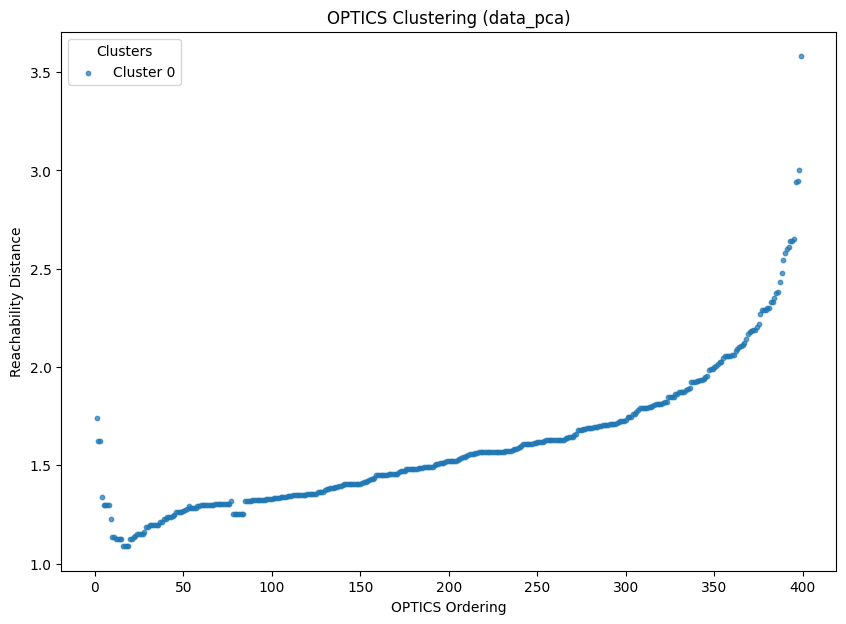

In [174]:
# adjusted parameters: 10 samples, 0.05 - less clear borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=10, xi=0.05, min_cluster_size=0.025, metric="euclidean")
optics_clusters=optics.fit_predict(data_pca)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.legend(title="Clusters")
plt.show()

[-1  0]
Number of clusters: 1


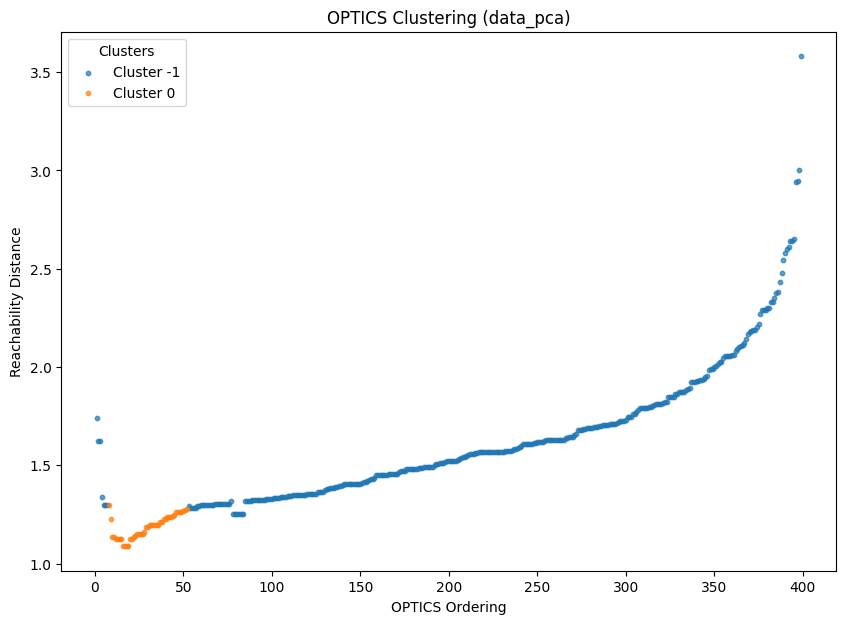

In [175]:
# adjusted parameters: 10 samples, 0.1 - less clear borders, min_cluster_size 2.5% of data
optics = OPTICS(min_samples=10, xi=0.01, min_cluster_size=0.025, metric="euclidean")
optics_clusters=optics.fit_predict(data_pca)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_pca))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_pca)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Even halfing the min_cluster_size does not yield any different results, meaning that even with low xi value and low min_cluster_size, the OPTICS clustering only produces one very small cluster and a lot of noise.

**Final Evaluation**

The OPTICS clustering experiments did not yield good clusterings on the data_pca dataset.
Even when reducing the density border requirements and the minimum amount of samples needed for a cluster, the method only finds one cluster. This also fits the reachability diagram, which shows one dip - where the one cluster is - and the gradually goes up without dipping into new clusters.

**Dataset: data_vt**

**Distance Function**

For data_vt I have again chosen the euclidean distance function for the same reasons as for data_pca. Additionally, data_vt is even more reduced than data_pca and the scaling wiht MinMax Scaler makes magnitudes very comparable. Therefore, I am using euclidean distance in the following experiments.

**Experiments with parameters**

In the following I am experimenting with the parameters min_samples, xi and min_cluster_size (explanations see above in section on data_full)

[-1  0  1]
Number of clusters: 2


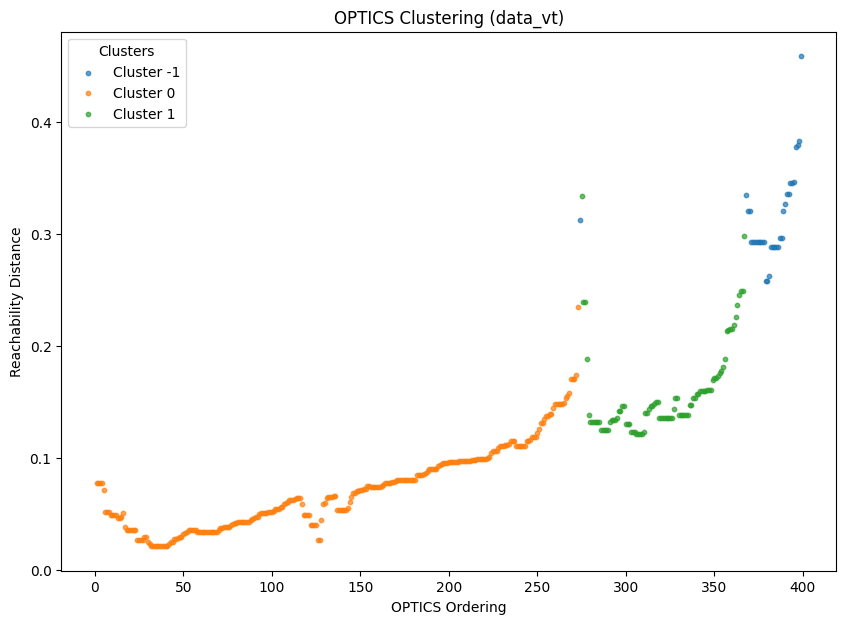

In [176]:
# same starting point: 10 samples, 0.1 - clear borders, min_cluster_size 5% of data
# distance metric is euclidean again
optics = OPTICS(min_samples=10, xi=0.1, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

Interpretation: This time, the starting point yields two clusters and some noise, but the noise is proportionally smaller than the clusters. Furthermore, this also fits the plotted representation very well. There are two quite clear dips and then some noise. With some adjustments, the noise might become a cluster as well, as it is all in the same area. To investigate this, I will try lowering the xi value again.
I will conduct further experiments with the parameters to investigate their influence on data_vt as well, but the starting point is quite promising so far this time.

[-1  0  1]
Number of clusters: 2


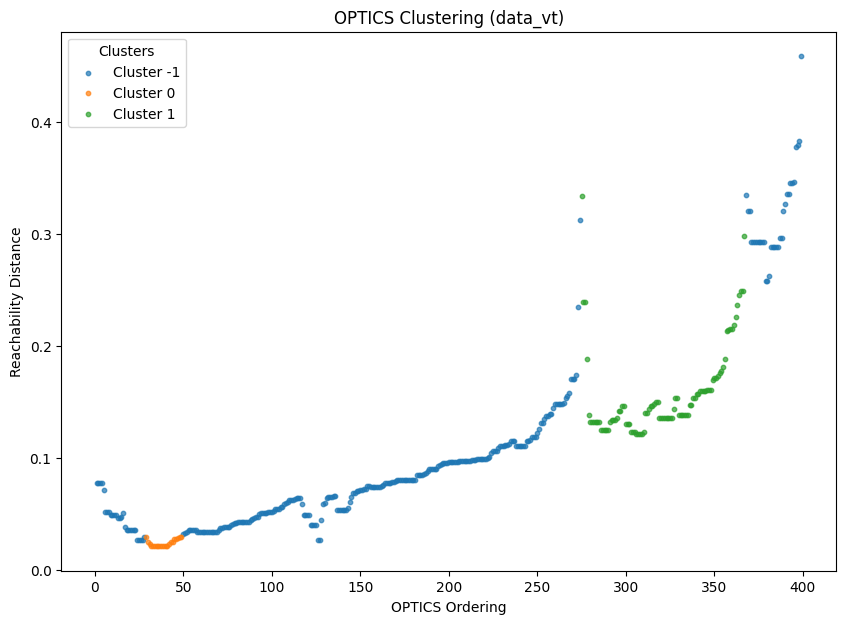

In [177]:
# adjusted parameters: 10 samples, 0.075 - less clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=10, xi=0.075, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

[-1  0]
Number of clusters: 1


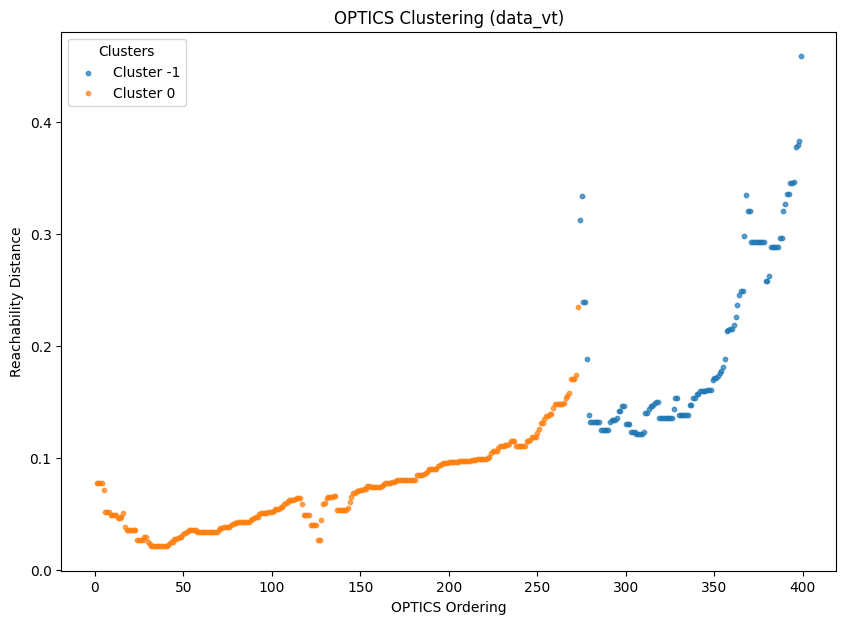

In [178]:
# adjusted: 10 samples, 0.2 - even clearer borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=10, xi=0.2, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

Interpretation: This experiment actually produced more noise. This could be because with a lowered density steepness needed, the points between the clusters are now hanging in between and cannot be assigned to one cluster, making them noise. When increasing xi to 0.2, the previously second cluster now is treated as noise because the density steepness threshold is now too high.
 I will go back to my starting xi value and now experimet with the min_samples to see its impact.

[-1  0  1]
Number of clusters: 2


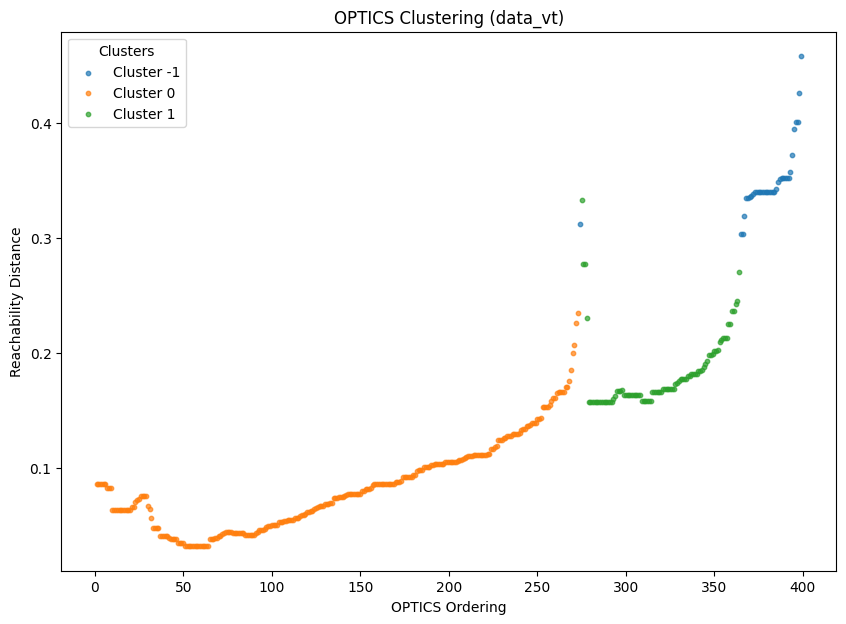

In [179]:
# adjusted parameters: 15 samples, 0.1 - clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=15, xi=0.1, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

[-1  0]
Number of clusters: 1


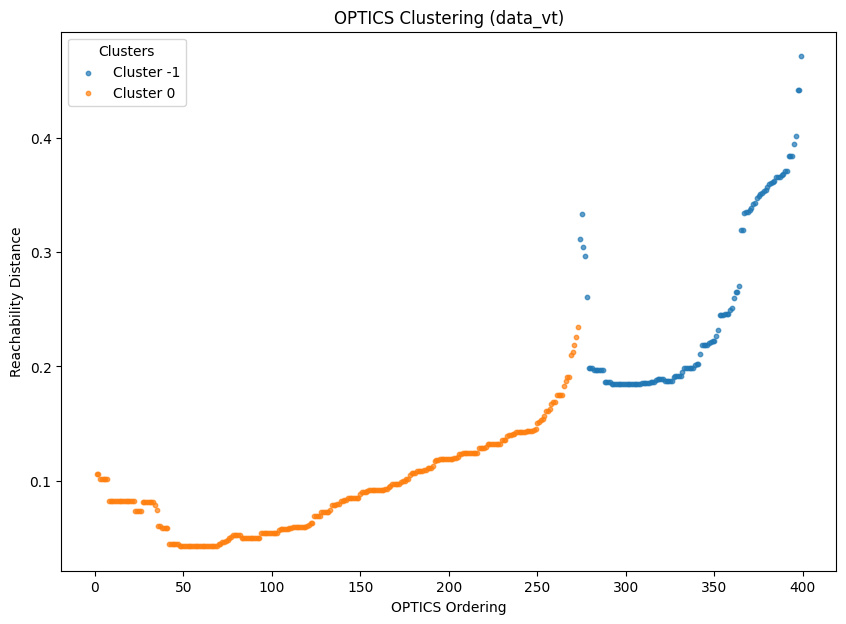

In [180]:
# adjusted parameters: 20 samples, 0.1 - clear borders, min_cluster_size 5% of data
optics = OPTICS(min_samples=20, xi=0.1, min_cluster_size=0.05, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

Interpretation: When changing the min_samples to 15, nothing changes in the number of clusters. Increasing it to 20 puts the points that previously formed the second cluster into noise points, meaning that there are less than 20 points in the neighborhood to form a core point for that cluster, which is why it is now noise. From this I am deriving that a minimum sample of 15 is a viable choice for my clustering project in this case. Next, I will experiment with min_cluster_size.

[-1  0  1]
Number of clusters: 2


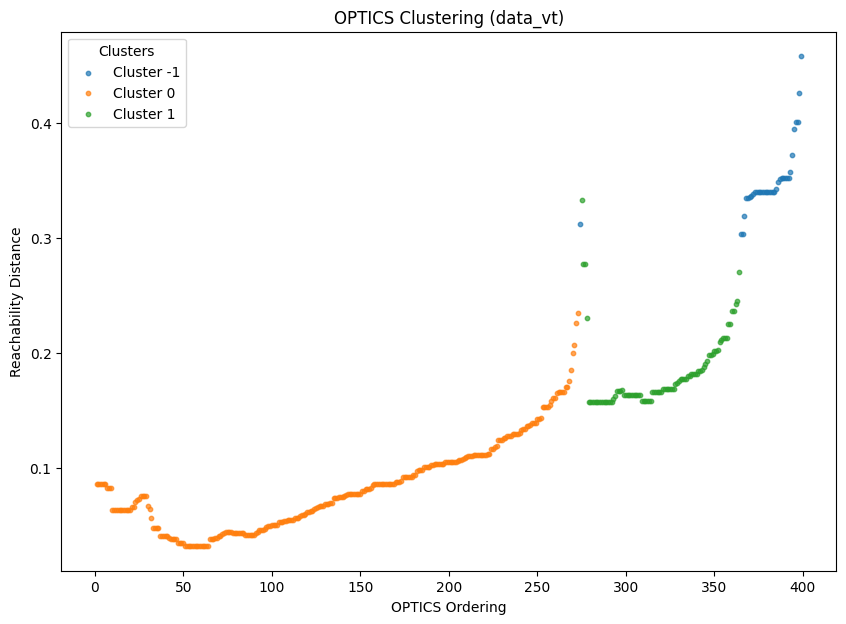

In [181]:
# adjusted parameters: 15 samples, 0.1 - clear borders, min_cluster_size 1% of data
optics = OPTICS(min_samples=15, xi=0.1, min_cluster_size=0.01, metric="euclidean")
optics_clusters=optics.fit_predict(data_vt)
clusters = np.unique(optics_clusters)
num_c = len(clusters) - 1 if -1 in clusters else len(clusters) # number of clusters, -1 is always noise
print(clusters) 
print(f"Number of clusters: {num_c}")

ordered_labels = optics.labels_[optics.ordering_]
reachability = optics.reachability_[optics.ordering_]
space = np.arange(len(data_vt))
plt.figure(figsize=(10, 7))
for c in clusters: 
    mask = (ordered_labels == c)
    plt.scatter(space[mask], reachability[mask],
                s=10, alpha=0.7, label=f"Cluster {c}")
plt.xlabel("OPTICS Ordering")
plt.ylabel("Reachability Distance")
plt.title("OPTICS Clustering (data_vt)")
plt.legend(title="Clusters")
plt.show()

Interpretation: Even decreasing the minimum cluster size to 1% (meaning 4 samples for my 400 rows) does not produce a change in the clusterings. Therefore, there are probably no other meaningful small clusters.

**Final Evaluation**

After experimenting will all three parameters, the parameters min_samples=15, xi=0.1, min_cluster_size=0.01 have produced the best result, as they show two fairly well defined cluster and some noise where the density only goes up without a further dip in the graph. The clusters are cleary visible in the plot. This is the most meaningful clustering produced by OPTICS on all three datasets.

### c) HAC

**Distance Function**

Since the data has not changed in the three datasets, I am using the same distance functions for the same reasons as with the OPTICS clusterings. Meaning I am using cosine for data_full and euclidean for data_pca and data_vt.

In [182]:
# initial agg for functions to be executable in seperate notebook cells without error
agg = cluster.AgglomerativeClustering(
    n_clusters=3, 
    metric="cosine", 
    linkage="complete", 
    compute_distances=True) # possible to adjust linkage matrix

# does not impact later function calls with different parameters

**Dataset: data_full**

In [183]:
# function for creating linkage
labels = agg.fit_predict(data_full)
def create_linkage(agg):
    n_samples = len(agg.labels_)
    counts = np.zeros(agg.children_.shape[0])
    for i, merge in enumerate(agg.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([agg.children_, agg.distances_,counts]).astype(float)
    return linkage_matrix
matrix=create_linkage(agg)

In [184]:
# function for clustering and drawing the dendrogram
def cluster_and_draw(df, affinity, linkage, distance_threshold):
    agg = cluster.AgglomerativeClustering(
        n_clusters=None, 
        distance_threshold= distance_threshold, # adjusting clusters instead of fixed clusters 
        metric=affinity, 
        linkage=linkage, 
        compute_distances=True
    )
    labels = agg.fit_predict(df)
    hierarchy.set_link_color_palette([ "purple", "pink", 'red', 'blue', "green"]) # colors clusters will appear in 
    plt.figure(figsize=(18,5))
    dendrogram(
        create_linkage(agg),
        color_threshold=distance_threshold, 
        orientation="left", 
        labels=df.index, 
        leaf_rotation=0)
    plt.xlabel("Distances")
    plt.ylabel("Cluster")
    plt.title("Dendrogram (data_full)")
    plt.tight_layout()
    plt.show()
    return labels

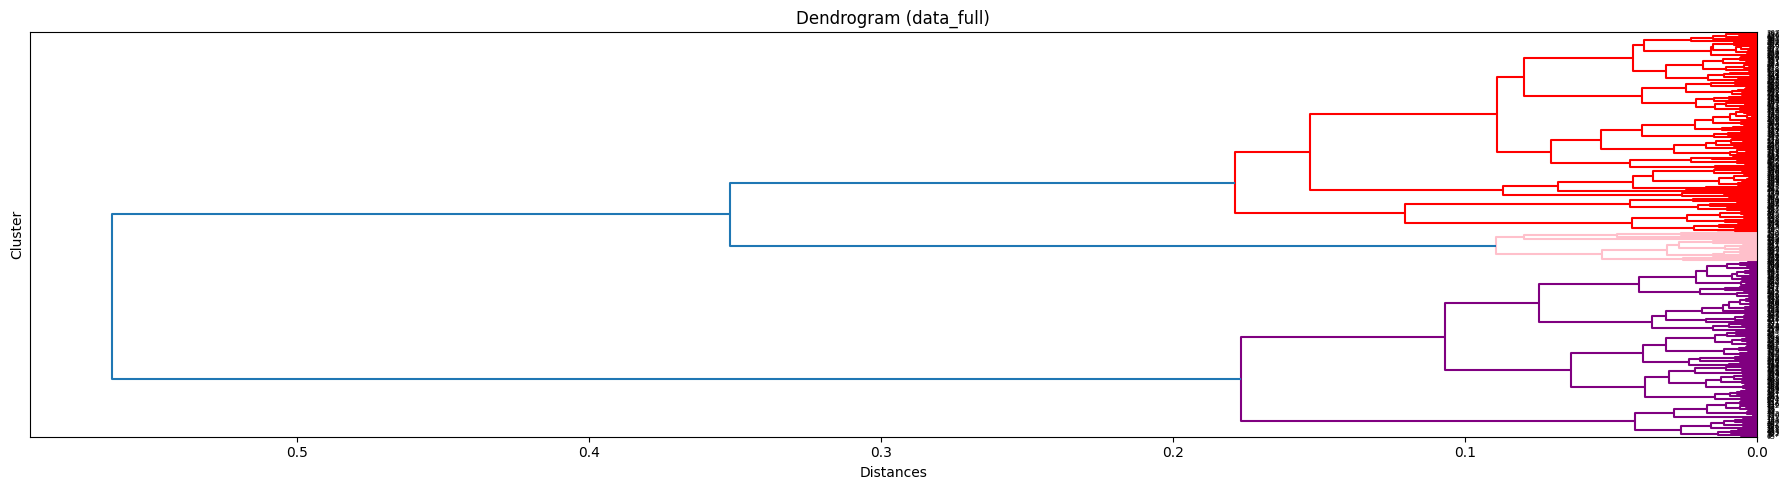

array([0, 1, 2])

In [185]:
# function call with distance metric, linkage method and cutoff threshold,
labels=cluster_and_draw(data_full, "cosine", "complete", 0.25)
# unique cluster labels 
np.unique(labels)

Interpretation: The chosen cutoff threshold and linkage parameter have produced three fairly good clusters as indicated by the colors. One of the clusters is significantly smaller than the other. Furthermore, the lines left of the clusters are very long indicating longer distances until the final groups merge. Therefore, clusters start merging quickly but the biggest two to three clusters are fairly well seperated. This is already a reasoable result. I will now try around with linkage functions.

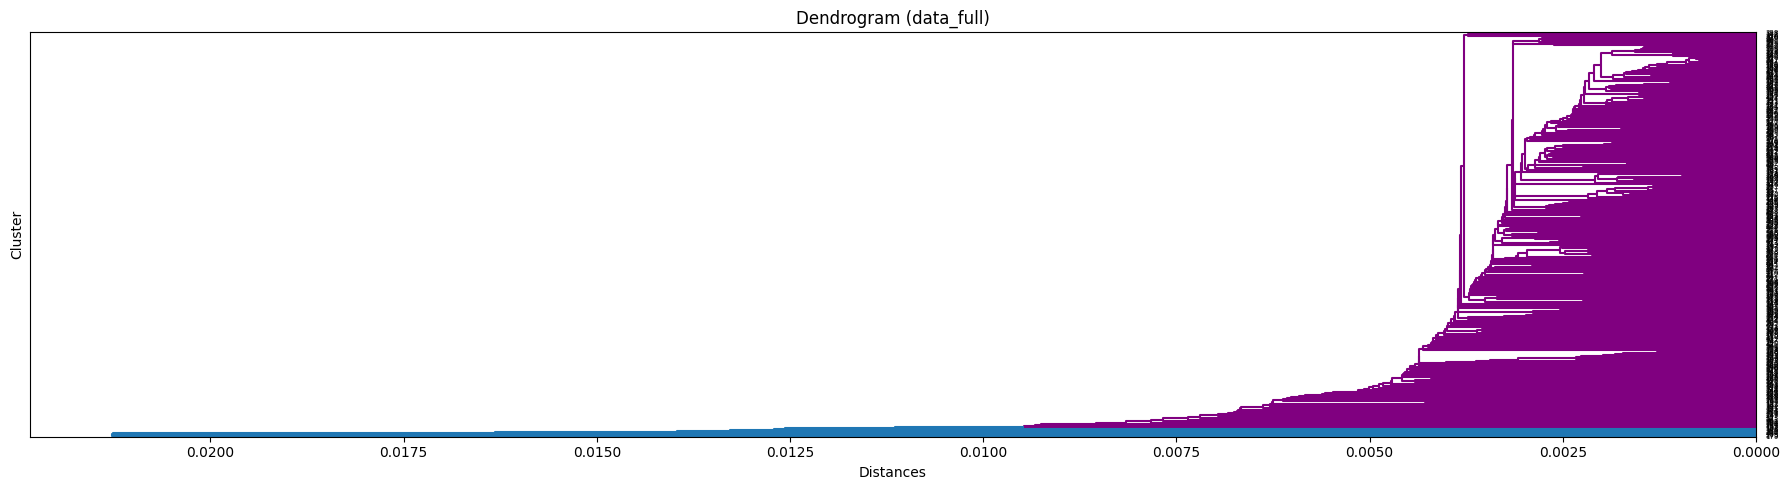

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [186]:
# changing linkage method and adjusting threshold to it 
labels=cluster_and_draw(data_full, "cosine", "single", 0.01)
np.unique(labels)

Interpretation: For single linkage, the threshold needs to be applied much lower to get any seperation of clusters. Threshold as high as 0.25 only result in one big cluster, as merges happen at much smaller distances, since single linkage looks at the minimum distance for points to be in one cluster. The above dendogram shows two colors with the red cluster being very dominant. An analysis of the unique labels shows 8 cluster. Therefore, this is not a suitable clustering for the data, as the clustering structure does not appear very meaningful.

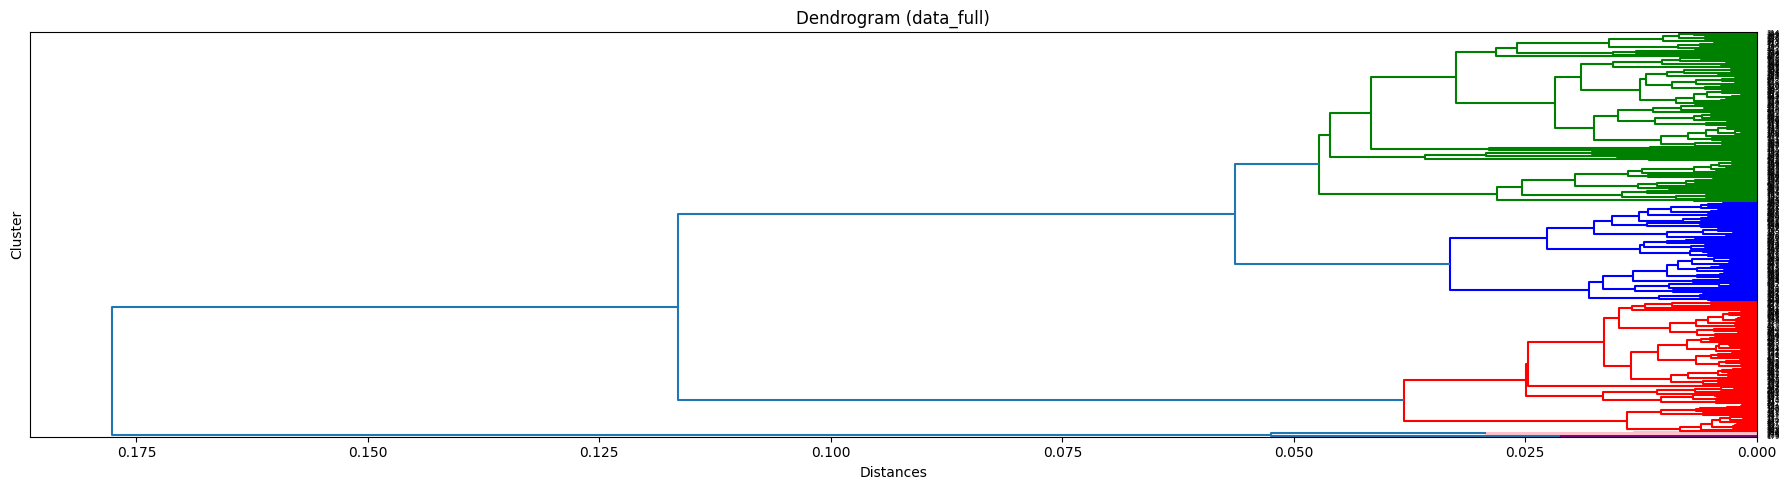

array([0, 1, 2, 3, 4])

In [187]:
# changing linkage method and adjusting threshold to it 
labels=cluster_and_draw(data_full, "cosine", "average", 0.05)
np.unique(labels)

Interpretation: This version again yields three distinct clusters below the threshold. The distances are much smaller, even if the structure is similar, compared to complete linkage. This is because average linkage compares the average distances. Furthermore, this version yielded 5 different cluster labels, but only three visible clusters. Some clusters might therefore by very close together, making them vanish in the visualization. Therefore, complete linkage seems best suitable for my project at this point. I will now experiment a little with the threshold. 

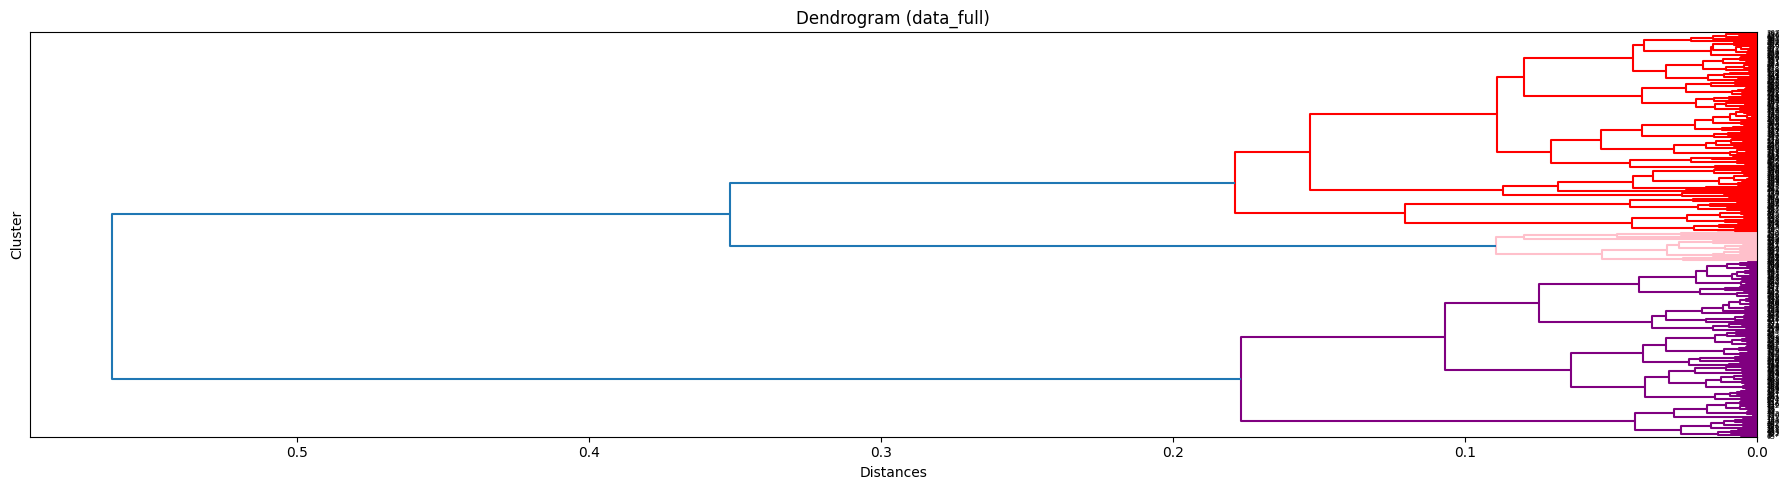

array([0, 1, 2])

In [188]:
# adjusting cutoff threshold
labels=cluster_and_draw(data_full, "cosine", "complete", 0.35)
np.unique(labels)

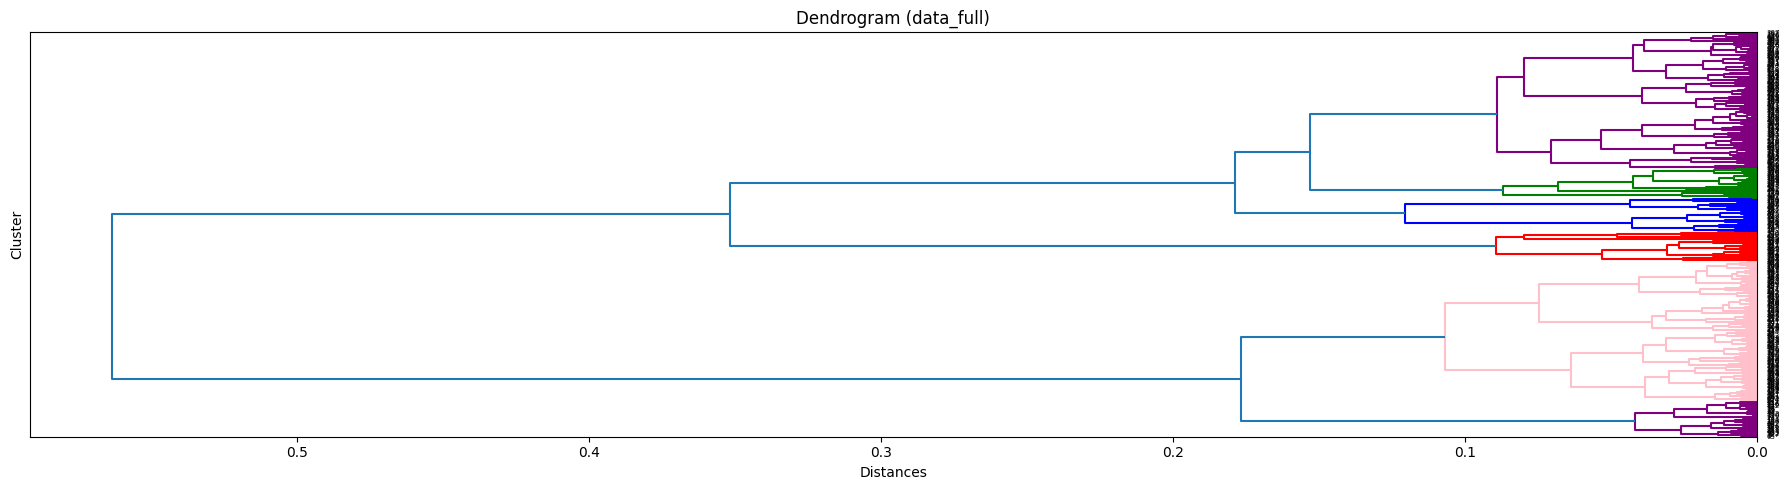

array([0, 1, 2, 3, 4, 5])

In [189]:
# adjusting cutoff threshold
labels=cluster_and_draw(data_full, "cosine", "complete", 0.15)
np.unique(labels)

Intepretation: Raising the threshold to 0.35 had no visual impact on the dendrogram. Lowering it to 0.15 resulted in 6 clusters that are visibly distinct from each other. Therefore, when lowering the distance threshold, more clusters appear, meaning that clusters are merging early. This means that there are potentially small, tight clusters in the data, that quickly merge into bigger clusters.

**Final Conclusion**

As the best option in this case I am choosing labels=cluster_and_draw(data_full, 'cosine', 'complete', 0.35)
np.unique(labels) as it produces three distinct clusters with a moderate distance threshold. This clustering approach results in three fairly well defined clusters, which are neither too fragmented nor too fuzzy.

**Dataset: data_pca**

In [190]:
labels = agg.fit_predict(data_pca)
# function for creating linkage
def create_linkage(agg):
    n_samples = len(agg.labels_)
    counts = np.zeros(agg.children_.shape[0])
    for i, merge in enumerate(agg.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1 
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([agg.children_, agg.distances_,counts]).astype(float)
    return linkage_matrix

matrix=create_linkage(agg)

In [191]:
# function for clustering and drawing of dendrograms 
def cluster_and_draw(df, affinity, linkage, color_threshold):
    agg = cluster.AgglomerativeClustering(
        n_clusters=None, 
        distance_threshold= color_threshold,
        metric=affinity, 
        linkage=linkage, 
        compute_distances=True
    )
    labels = agg.fit_predict(df)
    hierarchy.set_link_color_palette([ "purple", "pink", 'red', 'blue', "green"]) # colors assignee to clusters
    plt.figure(figsize=(18,5)) 
    dendrogram(
        create_linkage(agg),
        color_threshold=color_threshold, 
        orientation="left", 
        labels=df.index, 
        leaf_rotation=0)
    plt.xlabel("Distances")
    plt.ylabel("Cluster")
    plt.title("Dendrogram (data_pca)")
    plt.tight_layout()
    plt.show()
    return labels

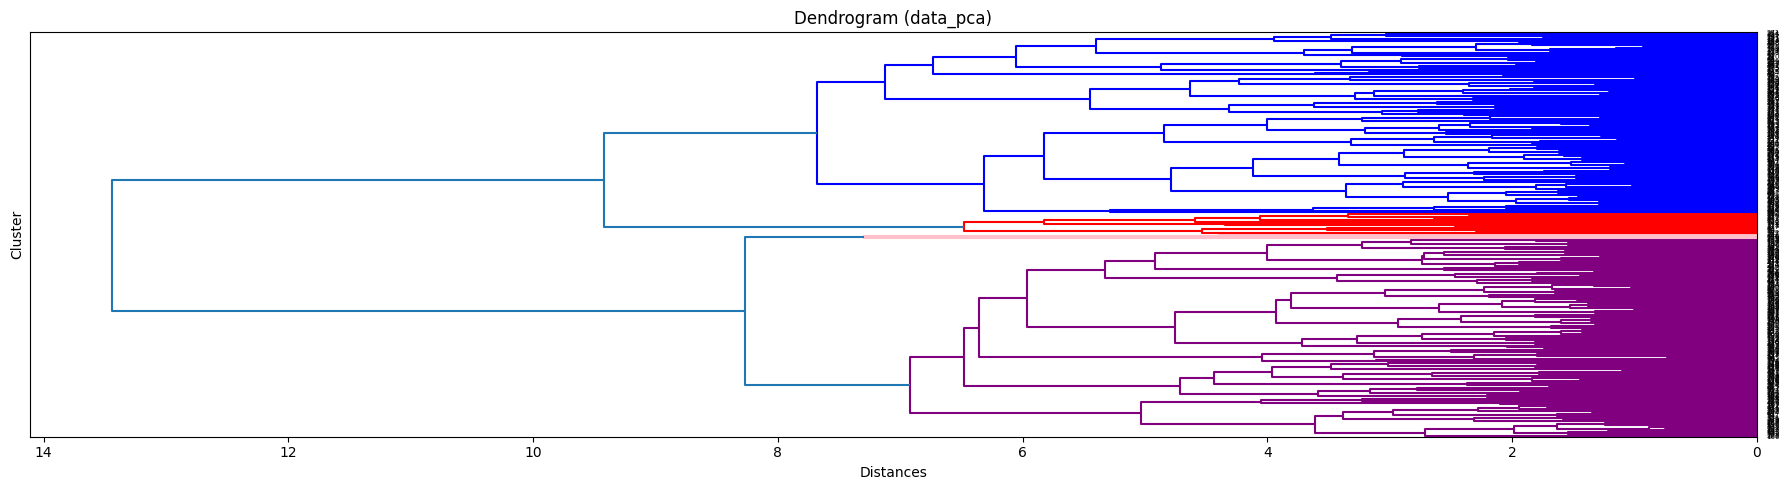

array([0, 1, 2, 3])

In [192]:
# function call with distance metric, linkage method and cutoff threshold
labels=cluster_and_draw(data_pca, "euclidean", "complete", 8)
# unique cluster labels
np.unique(labels)

Interpretation: I am using the same linkage as a starting point but I have adjusted the threshold, as the pca reduction changes the scale of distances, making a much larger threshold needed for a good clustering. The threshold 8 produced 4 clusters but two of them are very small and not very distinct. Therefore, this is not yet optimized.

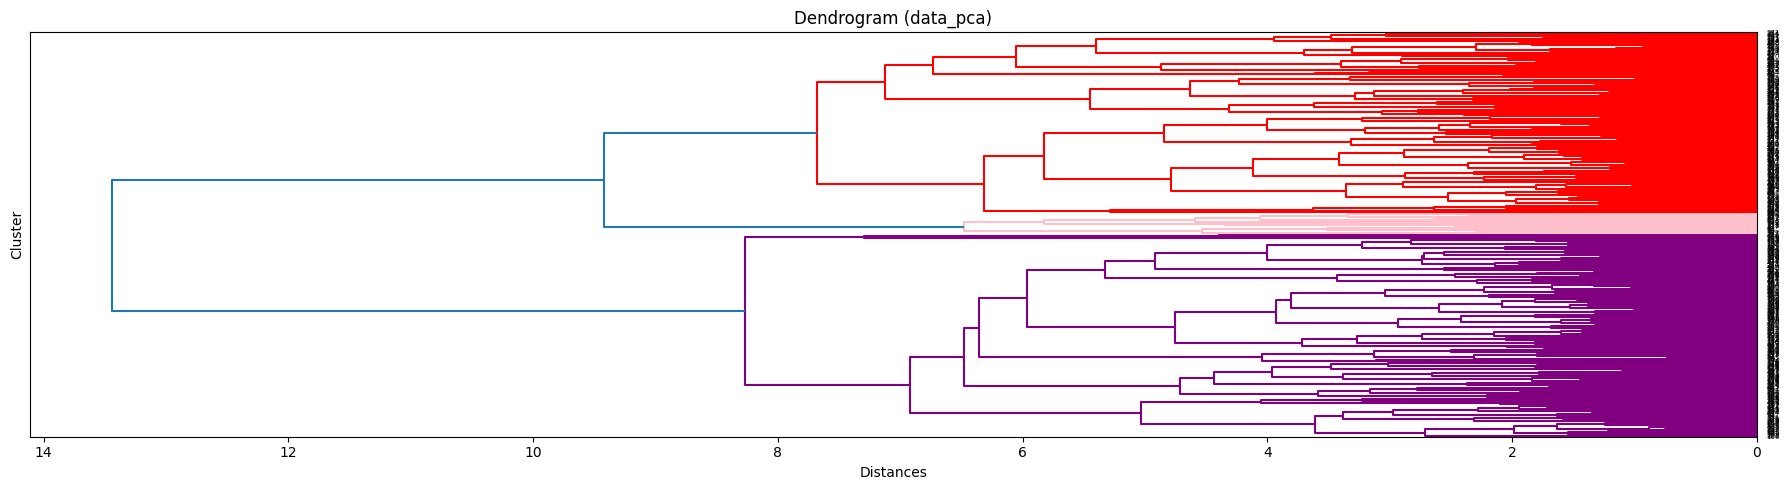

array([0, 1, 2])

In [193]:
# adjusting cutoff threshold
labels=cluster_and_draw(data_pca, "euclidean", "complete", 9)
np.unique(labels)

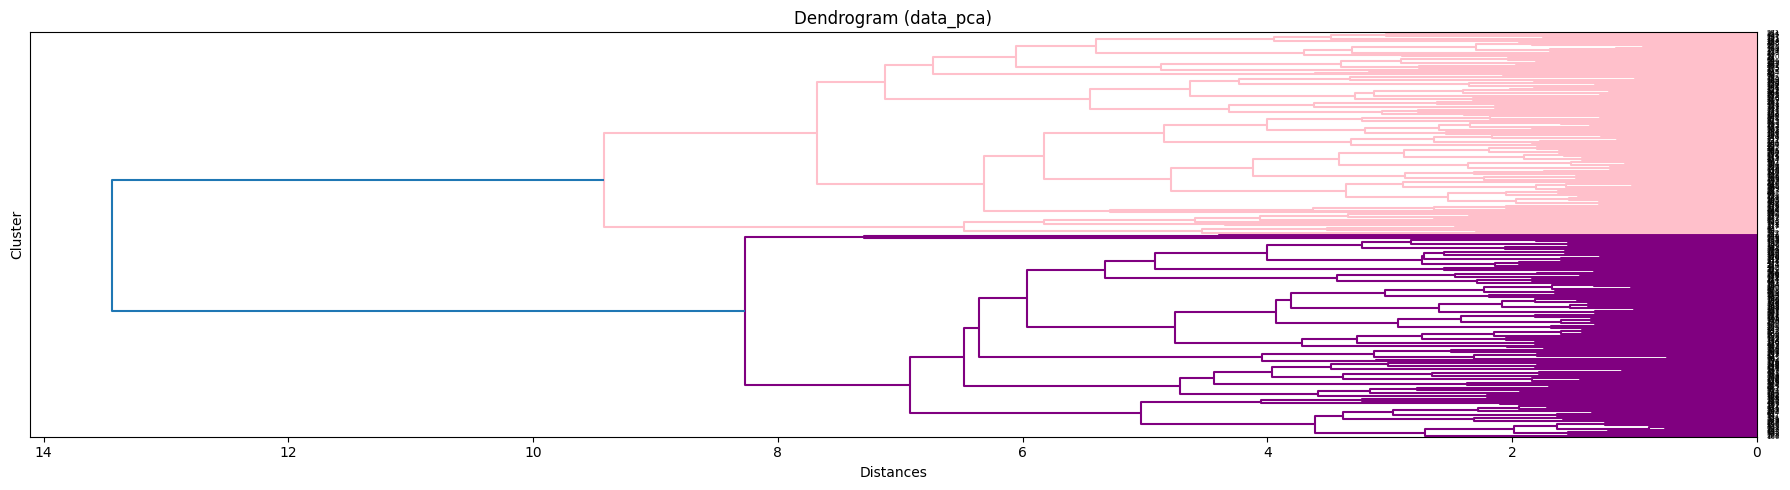

array([0, 1])

In [194]:
# adjusting cutoff threshold
labels=cluster_and_draw(data_pca, "euclidean", "complete", 9.5)
np.unique(labels)

Interpretation: When raising the distance threshold to 9 and then 9.5 first merges the two previously small clusters into one and then absorbing them into the two big clusters. This means that the four clusters are probably not well interpretable as two of them are very small. I would therefore favor the two big clusters, as they are very distinct. 

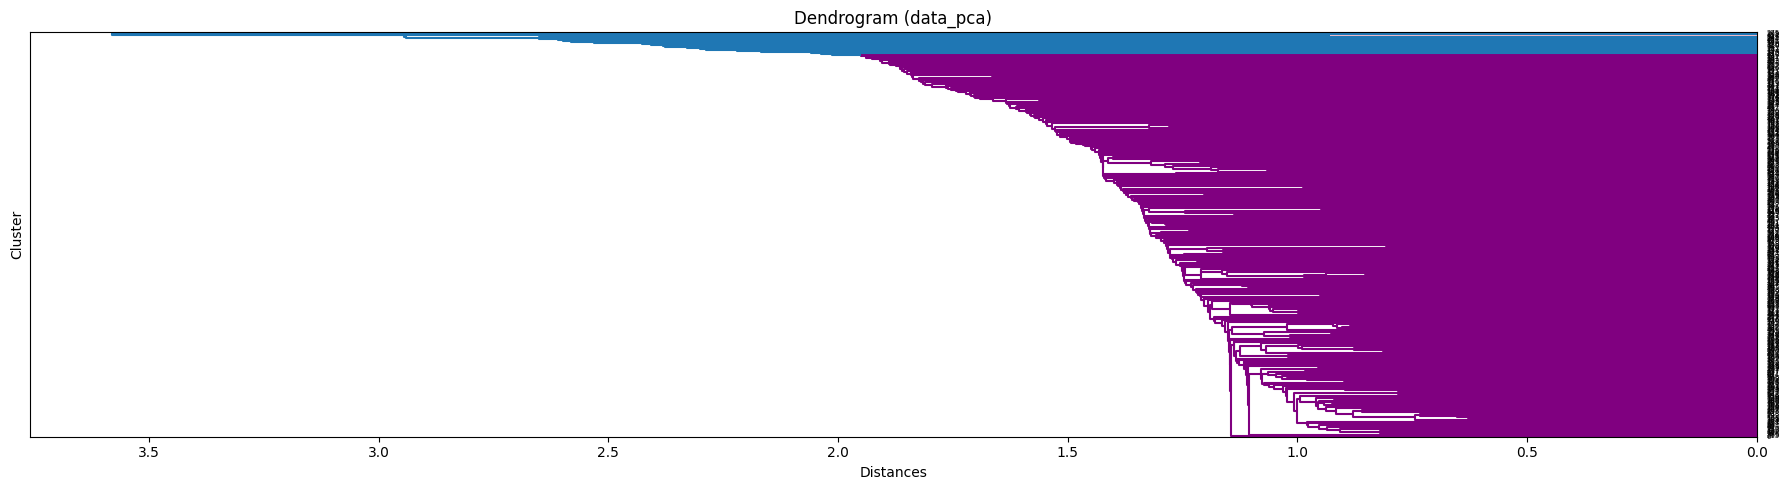

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20])

In [195]:
# experimenting with linkage method
labels=cluster_and_draw(data_pca, "euclidean", "single", 2)
np.unique(labels)

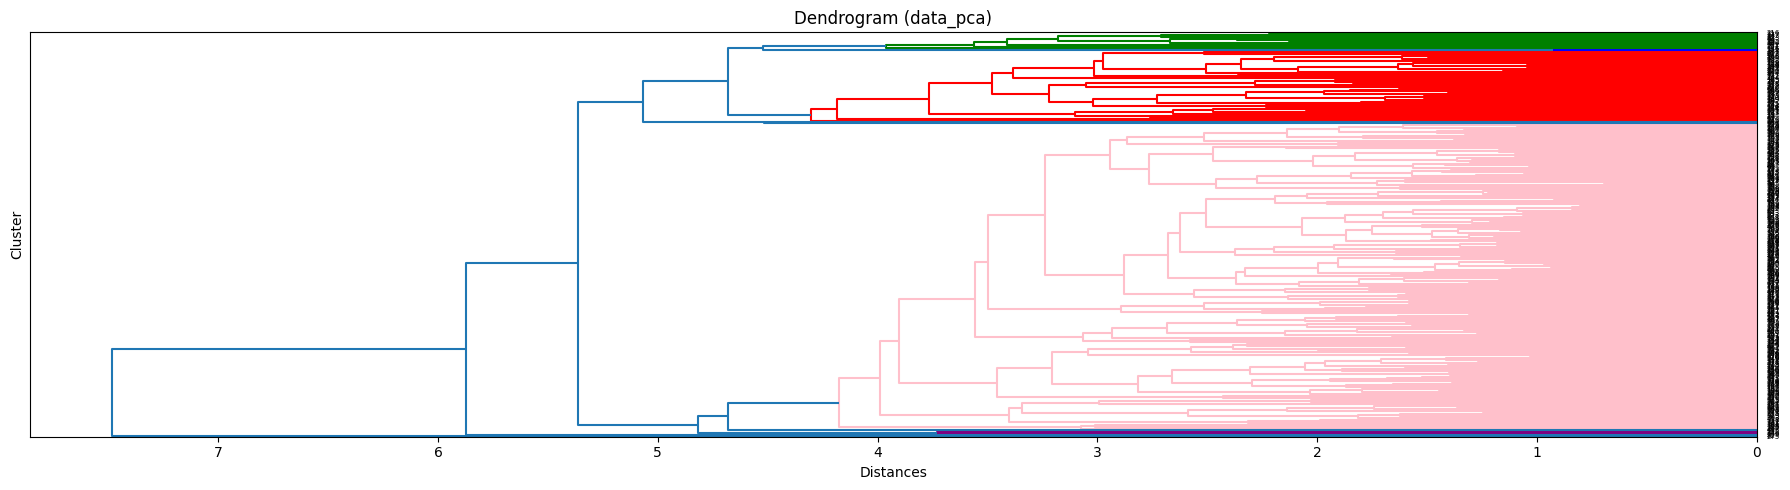

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9])

In [196]:
# experimenting with linkage method 
labels=cluster_and_draw(data_pca, "euclidean", "average", 4.5)
np.unique(labels)

Interpretation: Trying out different linkage methods resulted in similar plots as with the full data. Both times there are some distinct clusters visible, but they for example do not represent the uniqe labels well. Furthermore, the complete linkage clustering is easier to interpret, making visualizations for a project like mine more meaningful and easy to present.

**Final Conclusion**

As the best option in this case I am choosing labels=cluster_and_draw(data_pca, 'euclidean', 'complete', 9.5)
np.unique(labels) as it produces two strong, distinct clusters that have absorbed the very small other clustering, making them more robust.

**Dataset: data_vt**

In [197]:
labels = agg.fit_predict(data_vt)
# function for creating linkage
def create_linkage(agg):
    n_samples = len(agg.labels_)
    counts = np.zeros(agg.children_.shape[0])
    for i, merge in enumerate(agg.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1 
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count
    linkage_matrix = np.column_stack([agg.children_, agg.distances_,counts]).astype(float)
    return linkage_matrix

matrix=create_linkage(agg)

In [198]:
# function for clustering and drawing of dendrogram 
def cluster_and_draw(df, affinity, linkage, color_threshold):
    agg = cluster.AgglomerativeClustering(
        n_clusters=None, 
        distance_threshold=color_threshold,
        metric=affinity, 
        linkage=linkage, 
        compute_distances=True
    )
    labels = agg.fit_predict(df)
    hierarchy.set_link_color_palette([ "purple", "pink", "red", "blue", "green"]) # colors for the clusters
    plt.figure(figsize=(18,5))
    dendrogram(
        create_linkage(agg),
        color_threshold=color_threshold, 
        orientation="left", 
        labels=df.index, 
        leaf_rotation=0)
    plt.xlabel("Distances")
    plt.ylabel("Cluster")
    plt.title("Dendrogram (data_vt)")
    plt.tight_layout()
    plt.show()
    return labels

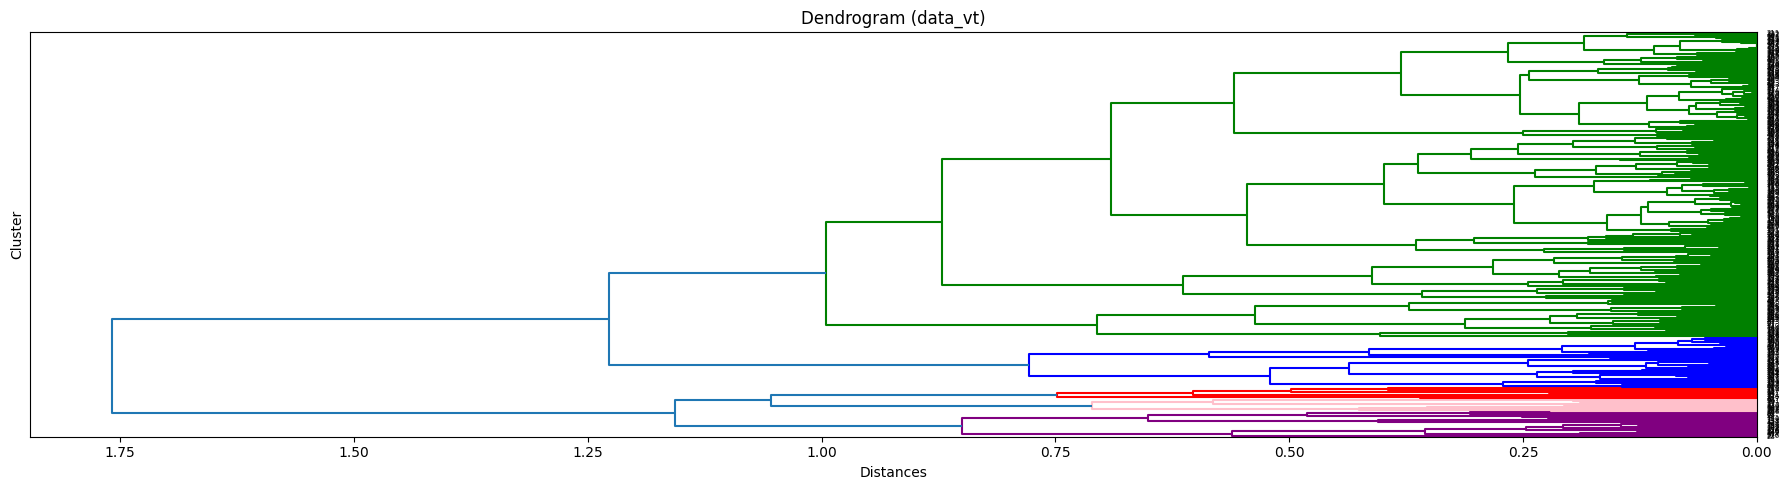

array([0, 1, 2, 3, 4])

In [199]:
# function call with distance metric, linkage method and cutoff threshold
labels=cluster_and_draw(data_vt, 'euclidean', "complete", 1.0)
# unique cluster labels 
np.unique(labels)

Interpretation: This version has yielded five distinct clusters, which is represented in the dendrogram that cuts at the maximum distance of 1.0. Still, there is one very dominant cluster, while the other clusters are much smaller. I will therefore slowly raise the threshold to see how quickly they will merge. 

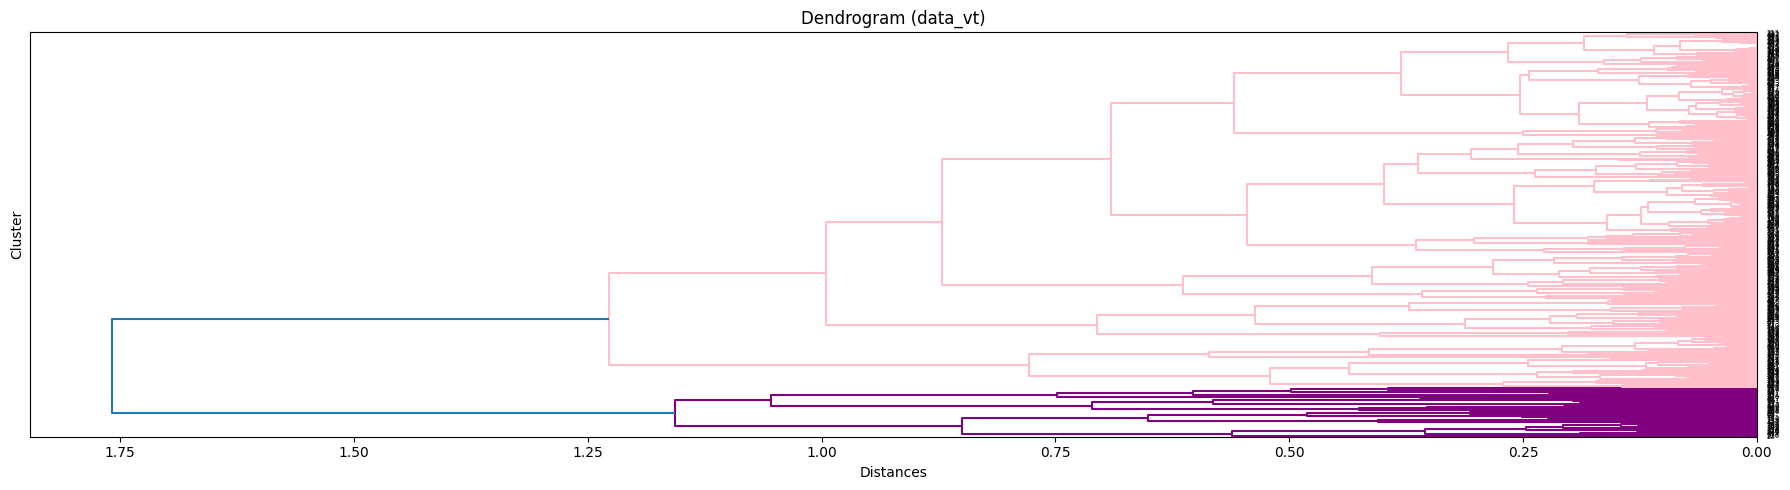

array([0, 1])

In [200]:
# adjusting cutoff threshold
labels=cluster_and_draw(data_vt, "euclidean", "complete", 1.25)
np.unique(labels)

Interpretation: Raising the distance threshold to 1.25 has resultet in two clusters. But the small clusters did not merge into one big one, but instead most of them were absorbed by the previous big cluster. This means that this could possibly also be one big cluster and then noise. Therefore, this version is probably not the most suitable.

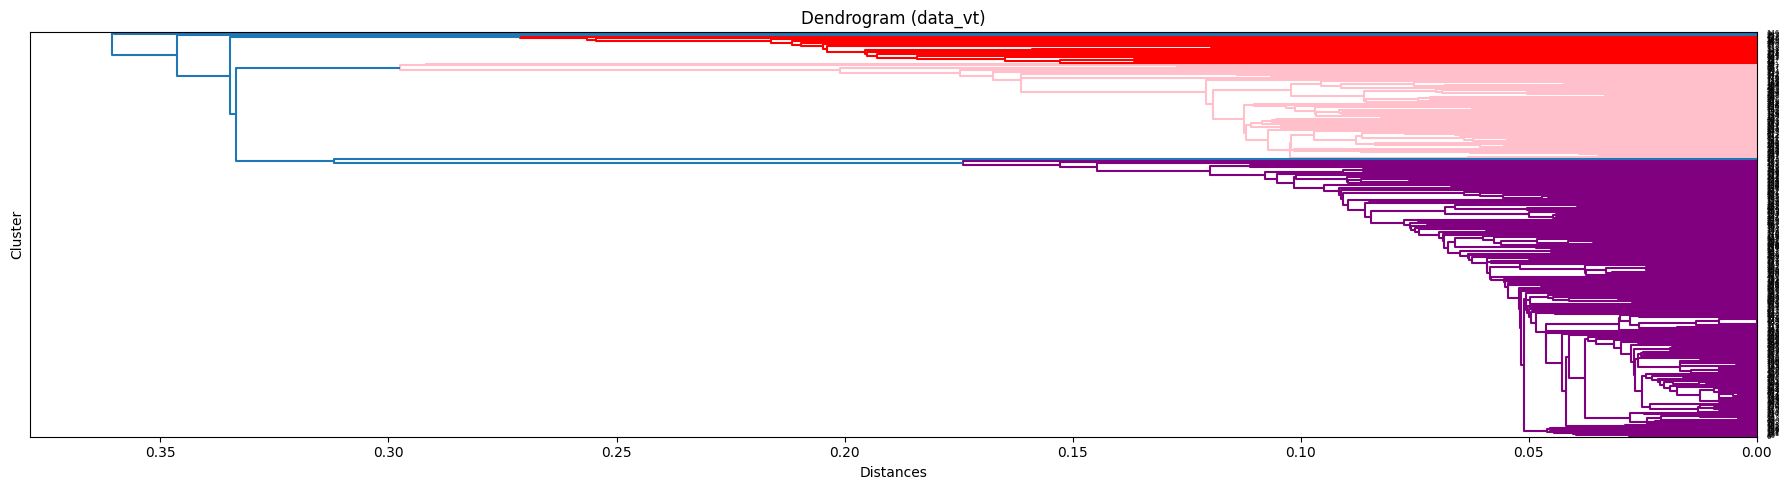

array([0, 1, 2, 3, 4, 5, 6])

In [201]:
# changing linkage method
labels=cluster_and_draw(data_vt, "euclidean", "single", 0.3)
np.unique(labels)

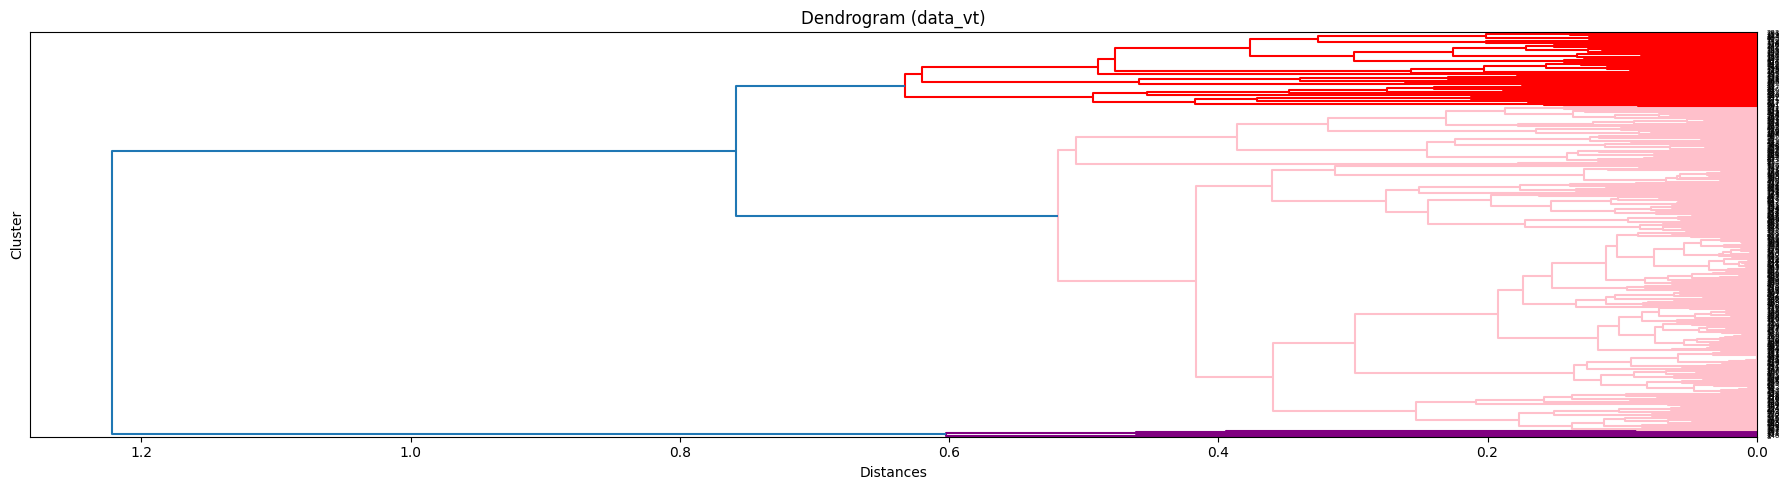

array([0, 1, 2])

In [202]:
# changing linkage method
labels=cluster_and_draw(data_vt, "euclidean", "average", 0.7)
np.unique(labels)

Interpretation: As with the other datasets, I am also experimenting with other linkage options. This time, the single link clustering yielded more distinct clusters, though the cluster count does not match the clusters visible in the dendrogram. For the average linking method, the dendrogram looks very similar to complete linkage clustering with a threshold of 1.25, as it has one big and one smaller cluster. In this case, the cluster count sits at three clusters though. Both linkage options are viable but since I have determined, that complete linkage dendrograms are easiest to interpret, which is important when presenting results for the project, and on average yield the most distinct clusters, I am not exploring the other options further.

**Final Conclusion**

I am choosing labels=cluster_and_draw(data_pca, 'euclidean', 'complete', 9.5) labels=cluster_and_draw(data_pca, 'euclidean', 'complete', 9.5) as the best option for data_vt. As it produces two strong, distinct clusters that have absorbed the very small other clustering, making them more robust. Furthermore, the potential that one of them is actually noise is very small, as both clusters are big and well structued.

**This concluded the clustering experiments of the draft stage of the project**

## Sources

For the reasoning behind k-means++ init, I have additionally read https://www.geeksforgeeks.org/machine-learning/k-means-vs-k-means-clustering-algorithm/

For the consideration of the distance functions, I have additionally (to class materials) used https://medium.com/data-science/9-distance-measures-in-data-science-918109d069fa 

For the interpretation of dendrograms I have read https://www.geeksforgeeks.org/python/scipy-cluster-hierarchy-dendrogram/